## Fitting Lyα Radiative Transfer Models with zELDA

In this notebook, we fit homogeneous thin expanding shell radiative transfer models using grids and MCMC implementation provided in the zELDA package (Gurung-Lopez et al. 2021). Note that zELDA has very particular dependencies, so may require its own dedicated venv to run this notebook.

In [1]:
import numpy as np
from astropy.io import fits
import astropy.table as aptb
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import Lya_zelda as Lya
import gc


from tangelo import io as tgio

In [2]:
# Where to get the spectra from
SPEC_SOURCE    = 'APER' # 'APER' or 'R21'
SPEC_TYPE      = '2fwhm_opt' # type of spectrum, e.g. '1fwhm' for 'aper' or 'noweight_skysub' for 'R21'

# Where to look for spectra
spec_dir = tgio.get_r21_spectra_dir if SPEC_SOURCE == 'R21' else tgio.get_aper_spectra_dir
filepattern = lambda iden: f"{'spec_' if SPEC_SOURCE == 'R21' else ''}{iden}_{SPEC_TYPE}.fits"

# Using this we define the function used to load spectra
spec_meth = lambda iden, cluster: tgio.load_spec(cluster, iden, '', spec_type=SPEC_TYPE, spec_source=SPEC_SOURCE)

In [3]:
# Load the megatable with LAEs
megatab_file = f'./megatables/lae_megatab_flagged_cpts_refit_{SPEC_TYPE}.fits'
megatab = aptb.Table(fits.open(megatab_file)[1].data)
print(f"Loaded {len(megatab)} LAEs from {megatab_file}")

# Remove rows with no significant Lyman alpha
megatab = megatab[(megatab['SNRR'] > 5.0) + (megatab['SNRB'] > 5.0)]
megatab.sort(keys='z')
print(f"Filtered down to {len(megatab)} LAEs")

Loaded 650 LAEs from ./megatables/lae_megatab_flagged_cpts_refit_2fwhm_opt.fits
Filtered down to 490 LAEs


In [4]:
# Load the Lyman alpha model grids

# Function to isolate the grid loading process
def load_grid():
    """ Load the Lyman alpha radiative transfer grid with memory monitoring"""
    grids_location = '../lya_rt_grids/Grids'
    Lya.funcs.Data_location = grids_location
    
    Geometry = 'Thin_Shell_Cont'
    # Clear any previous loaded grids from memory
    if 'LyaRT_Grid' in globals():
        del LyaRT_Grid
    gc.collect()
    
    # Load the grid with memory monitoring
    return Lya.load_Grid_Line(Geometry, MODE='FULL')

LyaRT_Grid = load_grid()

In [5]:
def opfunc(x, a, b):
    """ Helper function that can be used to re-normalise a model by fitting it to data """
    return a * x + b

In [6]:
# Define physical parameters to be used in the script
from tangelo import constants as tgconst

# Get c from constants
c = tgconst.c
# Dictionary of wavelengths
wavedict = tgconst.wavedict

In [7]:
def is_absorber(tab, wavedict, sig = 3.0, n = 1):
    tv = np.zeros(len(tab)).astype(int)
    for line in wavedict:
        if line == 'LYALPHA':
            continue
        else:
            try:
                tv += ((tab[f'SNR_{line}'] < -sig) 
                       * (tab[f'SNR_{line}'] > -1000.)
                       * (tab[f'FLAG_{line}'] != 'c')).astype(int)
            except:
                continue
    return tv >= n

def is_emitter(tab, wavedict, sig = 3.0, n = 1):
    tv = np.zeros(len(tab)).astype(int)
    for line in wavedict:
        if line == 'LYALPHA':
            continue
        else:
            try:
                tv += ((tab[f'SNR_{line}'] > sig) 
                       * (tab[f'SNR_{line}'] < 1000.)
                       * (tab[f'FLAG_{line}'] != 'c')).astype(int)
            except:
                continue
    return tv >= n

In [8]:
# Print out the parameters and their values in the grid

print( 'The expansion velocity [km/s] is evaluated in : ')

print( LyaRT_Grid['V_Arr'    ] )

print( 'The logarithmic of the HI column density [cm**-2] is evaluated in : ')

print( LyaRT_Grid['logNH_Arr'] )

print( 'The logarithmic of the dust optical depth is evaluated in : ')

print( LyaRT_Grid['logta_Arr'] )

print( 'The logarithmic of the intrinsic equivalent width [A] is evaluated in : ')
print( LyaRT_Grid['logEW_Arr'] )

print( 'The logarithmic of the intrinsic line width [A] is evaluated in : ')
print( LyaRT_Grid['Wi_Arr'] )

The expansion velocity [km/s] is evaluated in : 
[   0   10   20   30   40   50   60   70   80   90  100  150  200  250
  300  350  400  450  500  550  600  650  700  750  800  850  900  950
 1000]
The logarithmic of the HI column density [cm**-2] is evaluated in : 
[17.   17.25 17.5  17.75 18.   18.25 18.5  18.75 19.   19.25 19.5  19.75
 20.   20.25 20.5  20.75 21.   21.25 21.5 ]
The logarithmic of the dust optical depth is evaluated in : 
[-4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0. ]
The logarithmic of the intrinsic equivalent width [A] is evaluated in : 
[-1.         -0.78947368 -0.57894737 -0.36842105 -0.15789474  0.05263158
  0.26315789  0.47368421  0.68421053  0.89473684  1.10526316  1.31578947
  1.52631579  1.73684211  1.94736842  2.15789474  2.36842105  2.57894737
  2.78947368  3.        ]
The logarithmic of the intrinsic line width [A] is evaluated in : 
[0.01 0.05 0.1  0.15 0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.2
 1.4  1.6  1.8  2.   2.2  2.4  2.6  2.8  3.   3.25 3.

In [9]:
# Sort the megatable by SNRR
megatab.sort('SNRR', reverse=True)

Processing source SP219 from cluster SMACS2031 with zELDA
Generating spectrum...
Loading aperture spectrum for SMACS2031 object SP219...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  6.69it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:24<00:00,  6.19it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 55.902098459310714


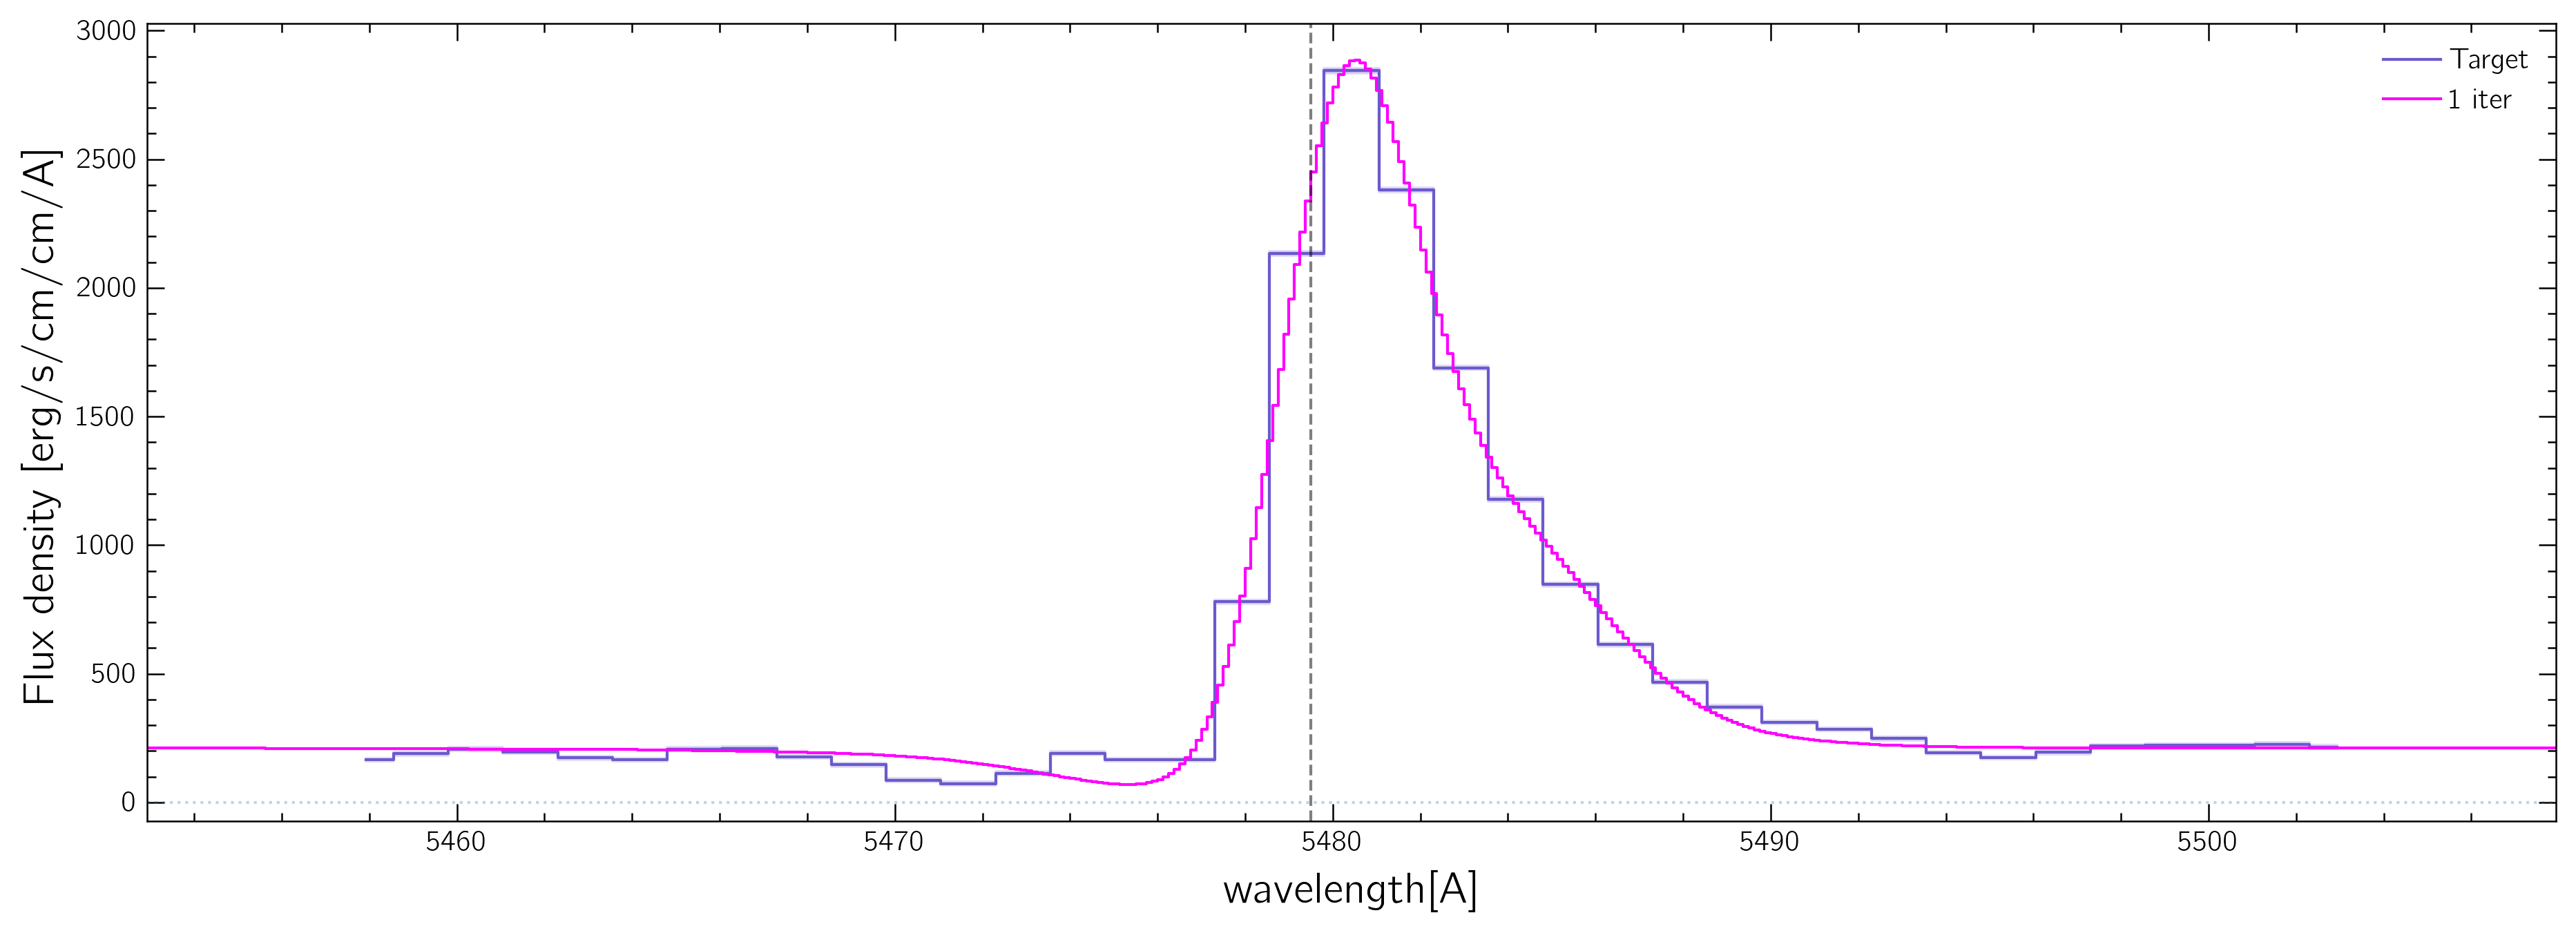

Done.
The measured redshift                                                     is 3.5073926478415007
The measured expasion velocity                                            is 175.65766224149064
The measured logarithm of the HI column density                           is 19.06485031431148
The measured dust optical depth                                           is 0.3806894200592319
The measured logarithm of the intrinsic equivalent width                  is 1.3316859962060281
The measured intrinsic width                                              is 0.08912265031952442
Processing source M195 from cluster MACS0940 with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0940 object M195...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:17<00:00,  5.86it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:24<00:00,  6.19it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 18.712182734333183


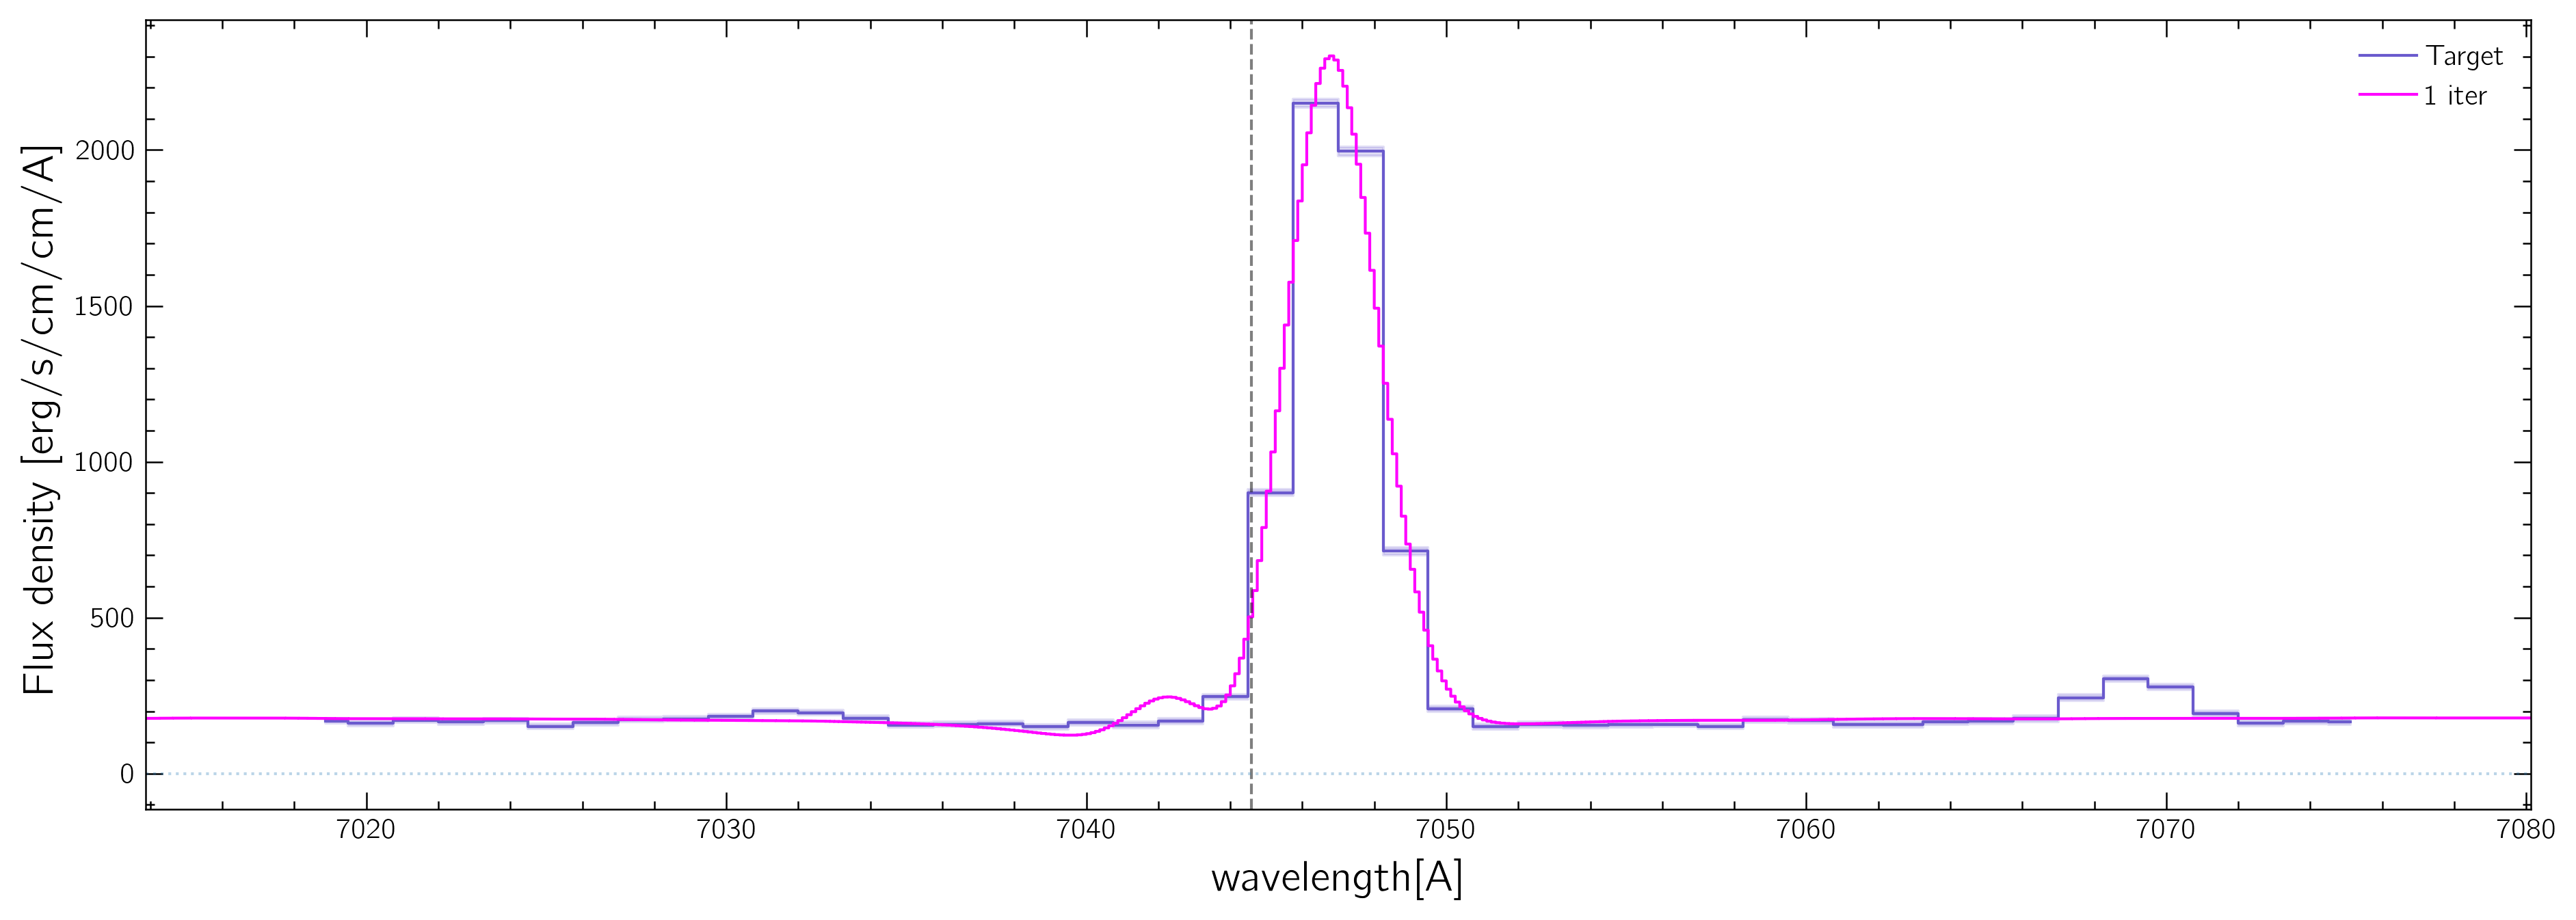

Done.
The measured redshift                                                     is 4.794811499266755
The measured expasion velocity                                            is 25.718494115019887
The measured logarithm of the HI column density                           is 18.99996759635622
The measured dust optical depth                                           is 0.9947763023142966
The measured logarithm of the intrinsic equivalent width                  is 1.7874273315955023
The measured intrinsic width                                              is 0.01037143168430979
Processing source P4556 from cluster RXJ1347 with zELDA
Generating spectrum...
Loading aperture spectrum for RXJ1347 object P4556...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.25it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.38it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
Genuinely high-dust fit over 95% confidence interval!
model reduced chi squared = 19.420053652927567


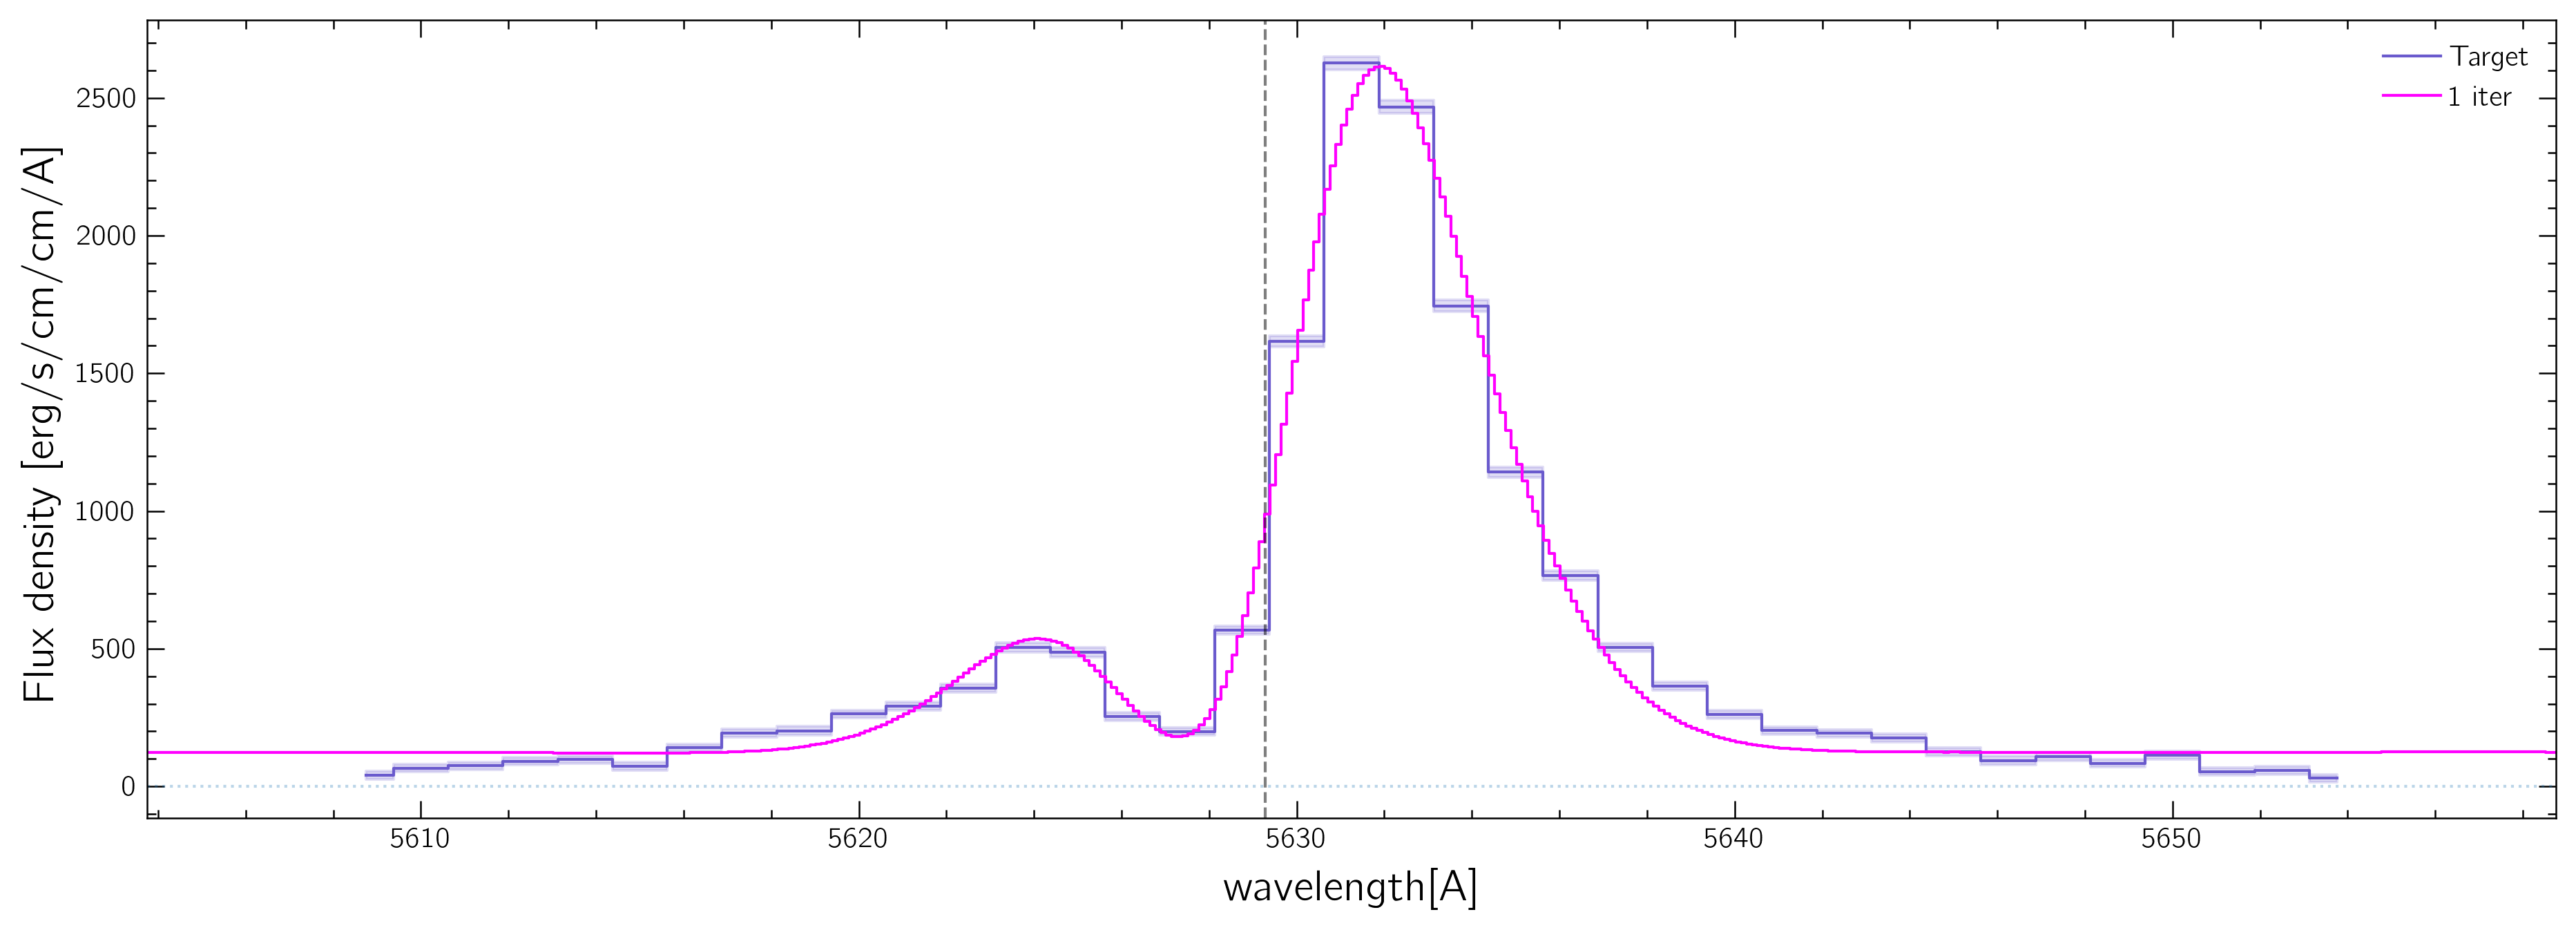

Done.
The measured redshift                                                     is 3.6306022773294426
The measured expasion velocity                                            is 99.97761718750922
The measured logarithm of the HI column density                           is 19.01136503835255
The measured dust optical depth                                           is 0.999682369487374
The measured logarithm of the intrinsic equivalent width                  is 1.7629108124960082
The measured intrinsic width                                              is 0.5130390882488979
Processing source SP183 from cluster MACS0940 with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0940 object SP183...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.05it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:24<00:00,  6.11it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 7.64838487934483


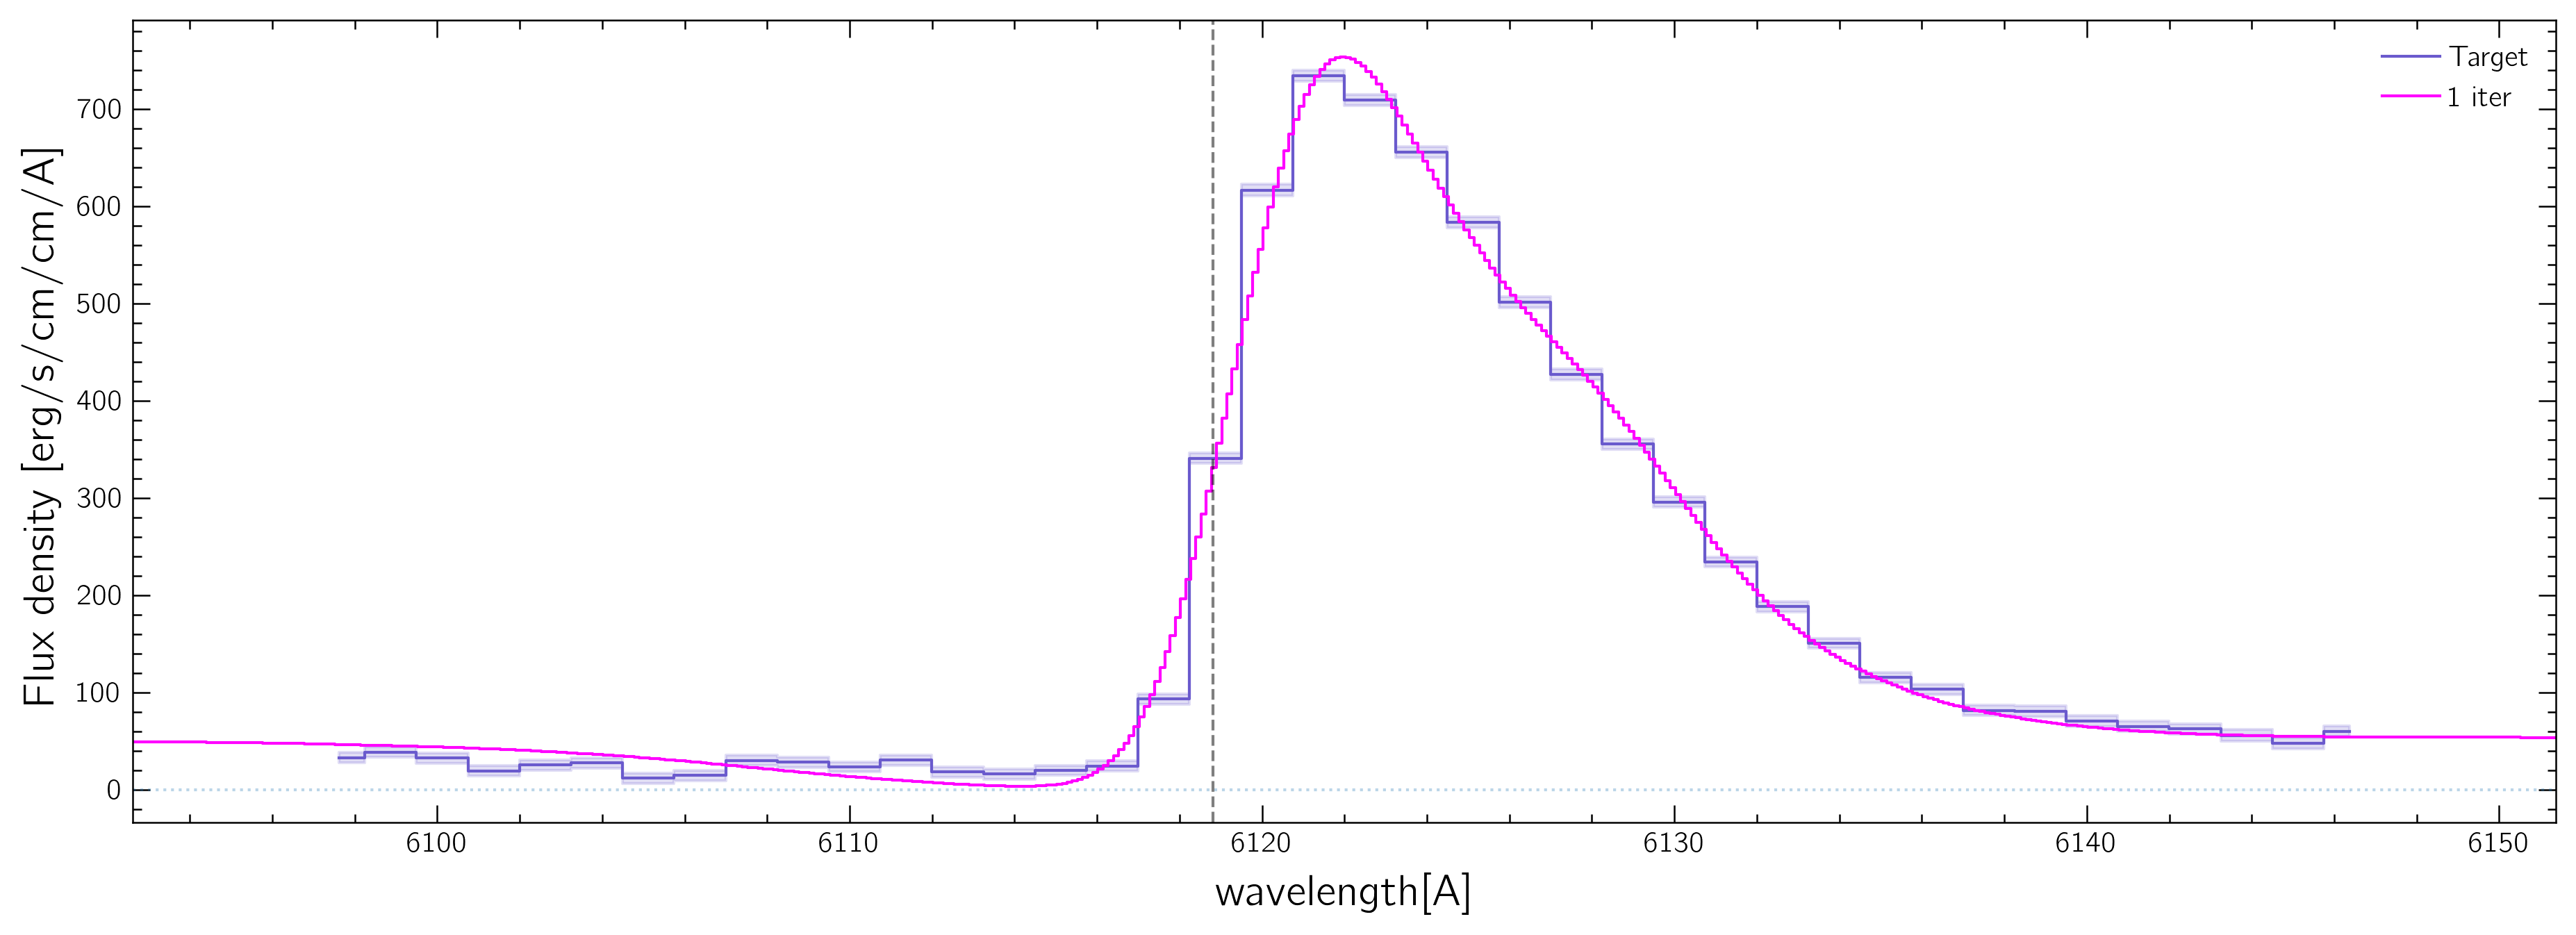

Done.
The measured redshift                                                     is 4.033280933700362
The measured expasion velocity                                            is 249.99968692456417
The measured logarithm of the HI column density                           is 19.802992115887015
The measured dust optical depth                                           is 0.5433360234694019
The measured logarithm of the intrinsic equivalent width                  is 1.704645776510469
The measured intrinsic width                                              is 0.32908106365757345
Processing source P2782 from cluster RXJ1347 with zELDA
Generating spectrum...
Loading aperture spectrum for RXJ1347 object P2782...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.25it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:25<00:00,  5.84it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 13.22872406898099


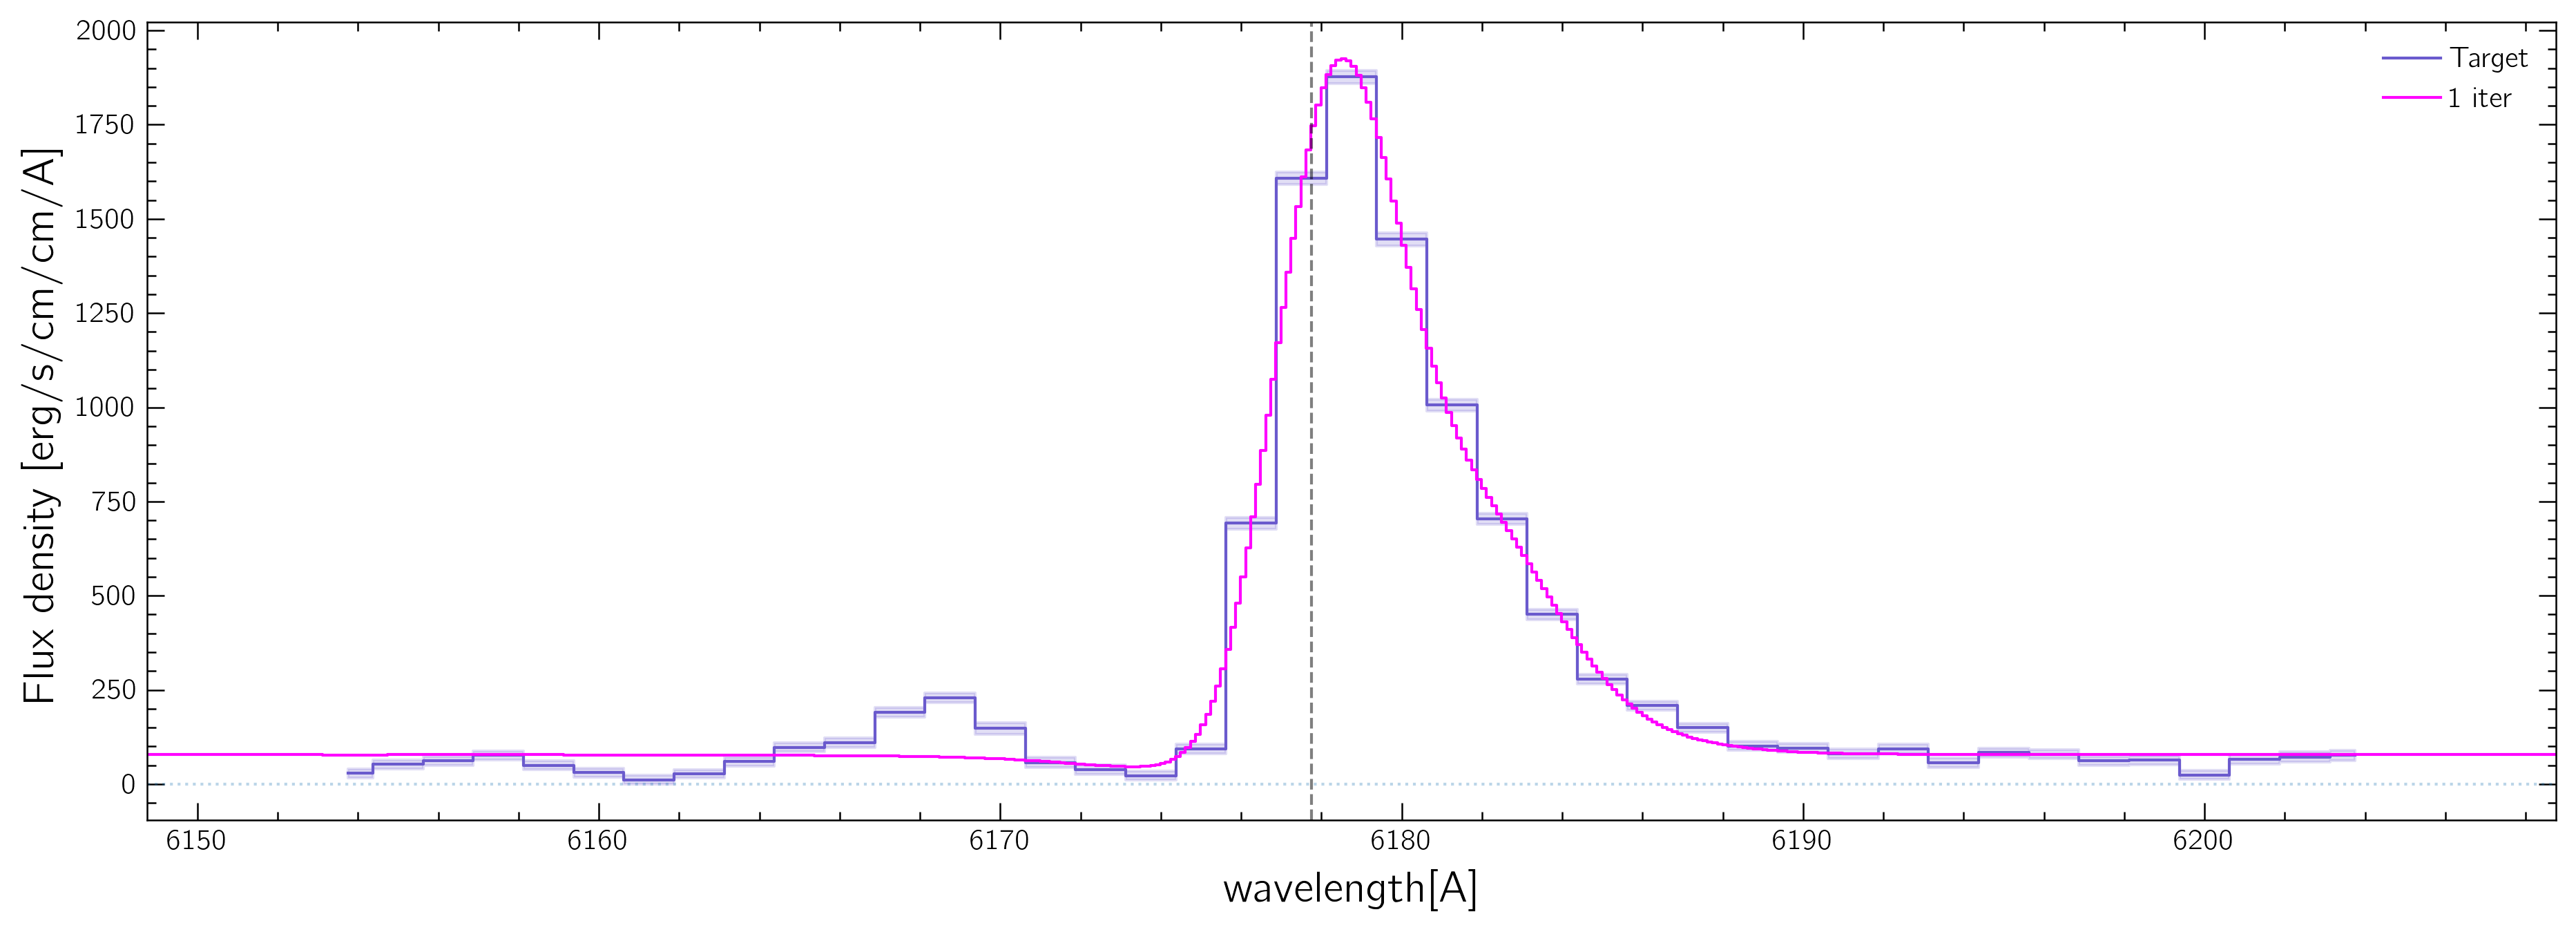

Done.
The measured redshift                                                     is 4.081775550943709
The measured expasion velocity                                            is 150.00254725148756
The measured logarithm of the HI column density                           is 18.7034573470319
The measured dust optical depth                                           is 0.09894874545009047
The measured logarithm of the intrinsic equivalent width                  is 1.4303745852877776
The measured intrinsic width                                              is 0.08003263755859011
Processing source SP8253 from cluster A370 with zELDA
Generating spectrum...
Loading aperture spectrum for A370 object SP8253...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.14it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.44it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 3.7889075116567112


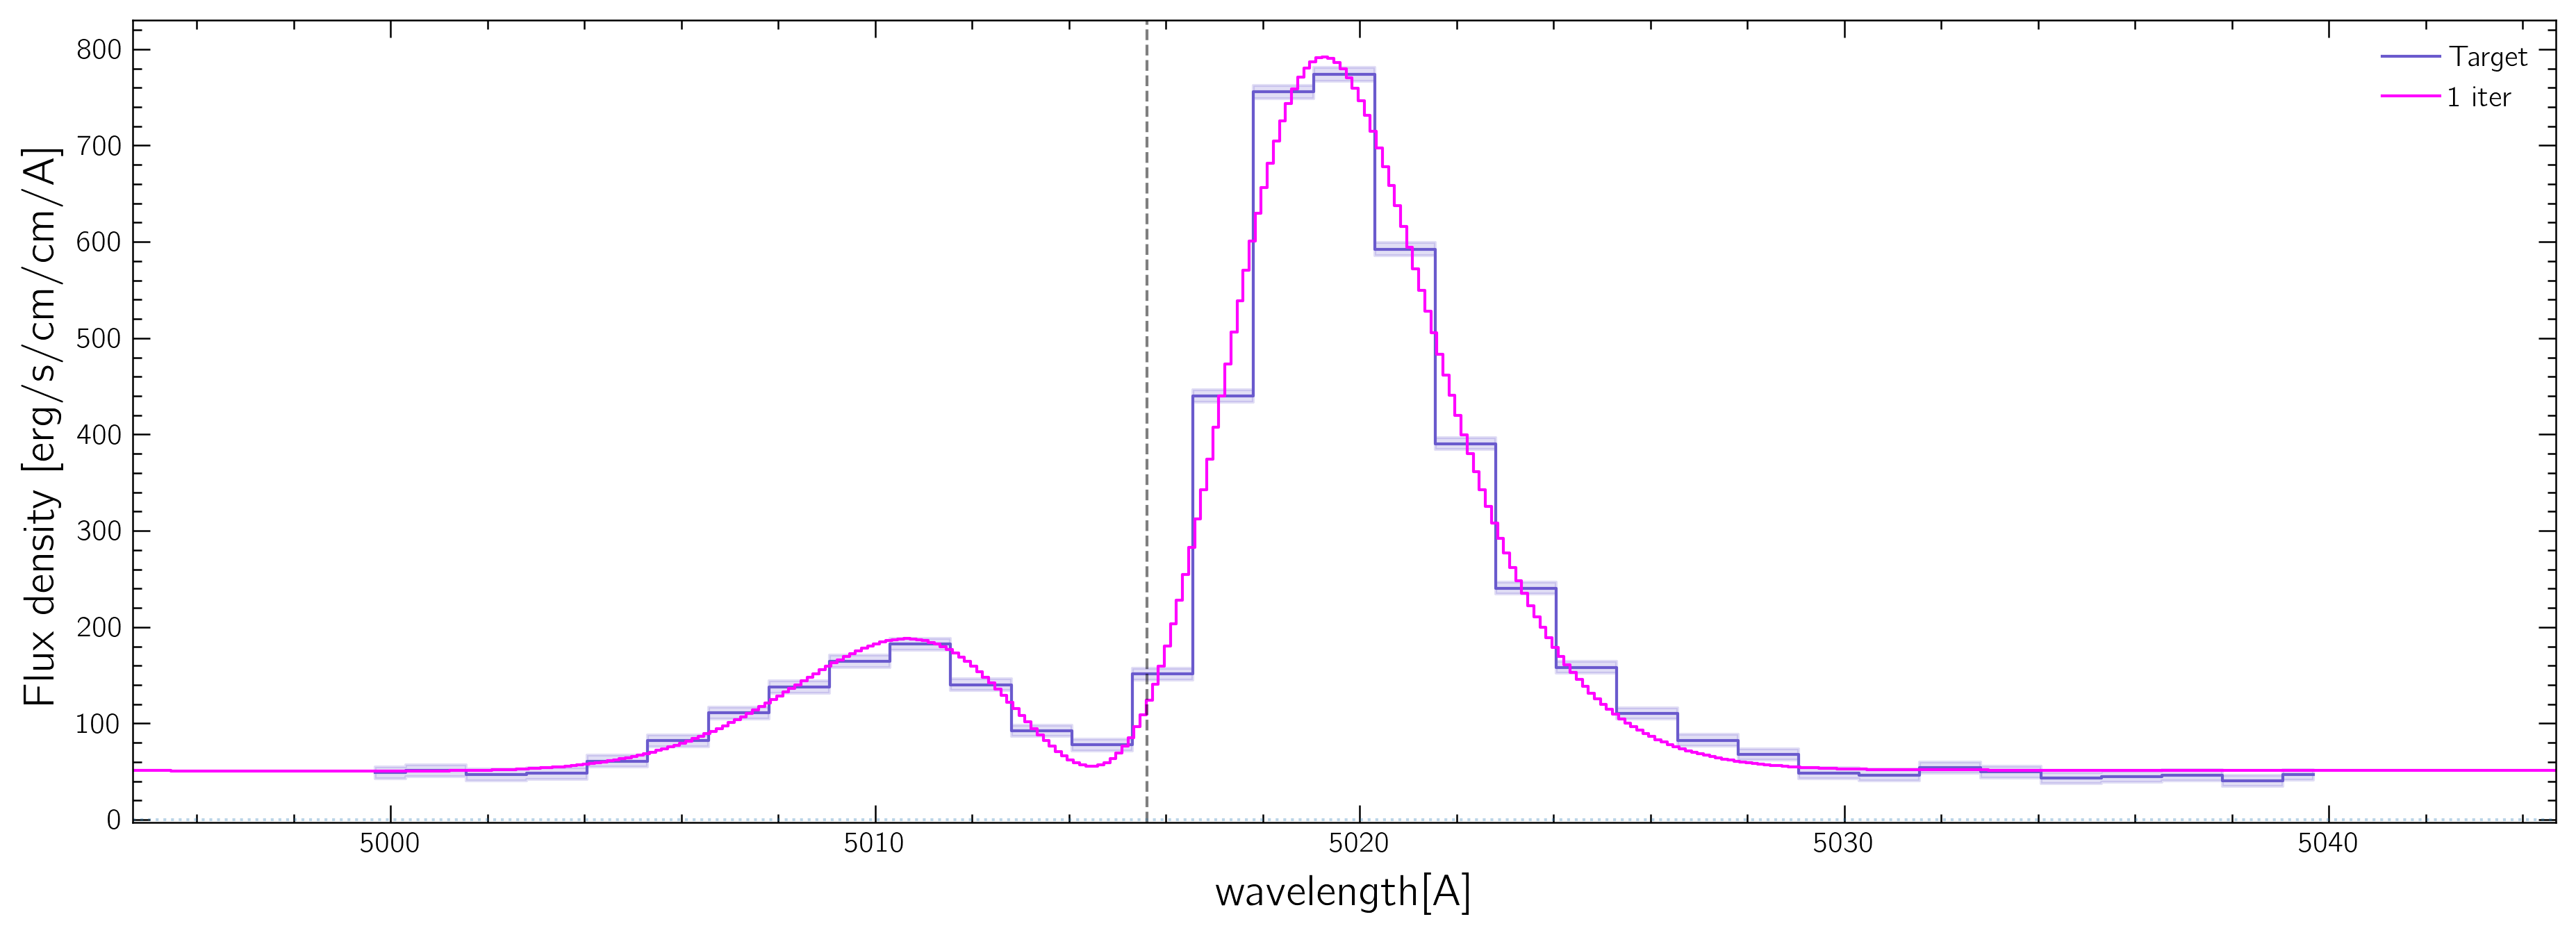

Done.
The measured redshift                                                     is 3.125799123698723
The measured expasion velocity                                            is 63.763140561096826
The measured logarithm of the HI column density                           is 19.49935718266132
The measured dust optical depth                                           is 0.17208871704150158
The measured logarithm of the intrinsic equivalent width                  is 1.565807014614292
The measured intrinsic width                                              is 0.8512248041192665
Processing source SP5408 from cluster A2744 with zELDA
Generating spectrum...
Loading aperture spectrum for A2744 object SP5408...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.85it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:25<00:00,  5.86it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
Genuinely high-dust fit over 95% confidence interval!
model reduced chi squared = 2.456019549908078


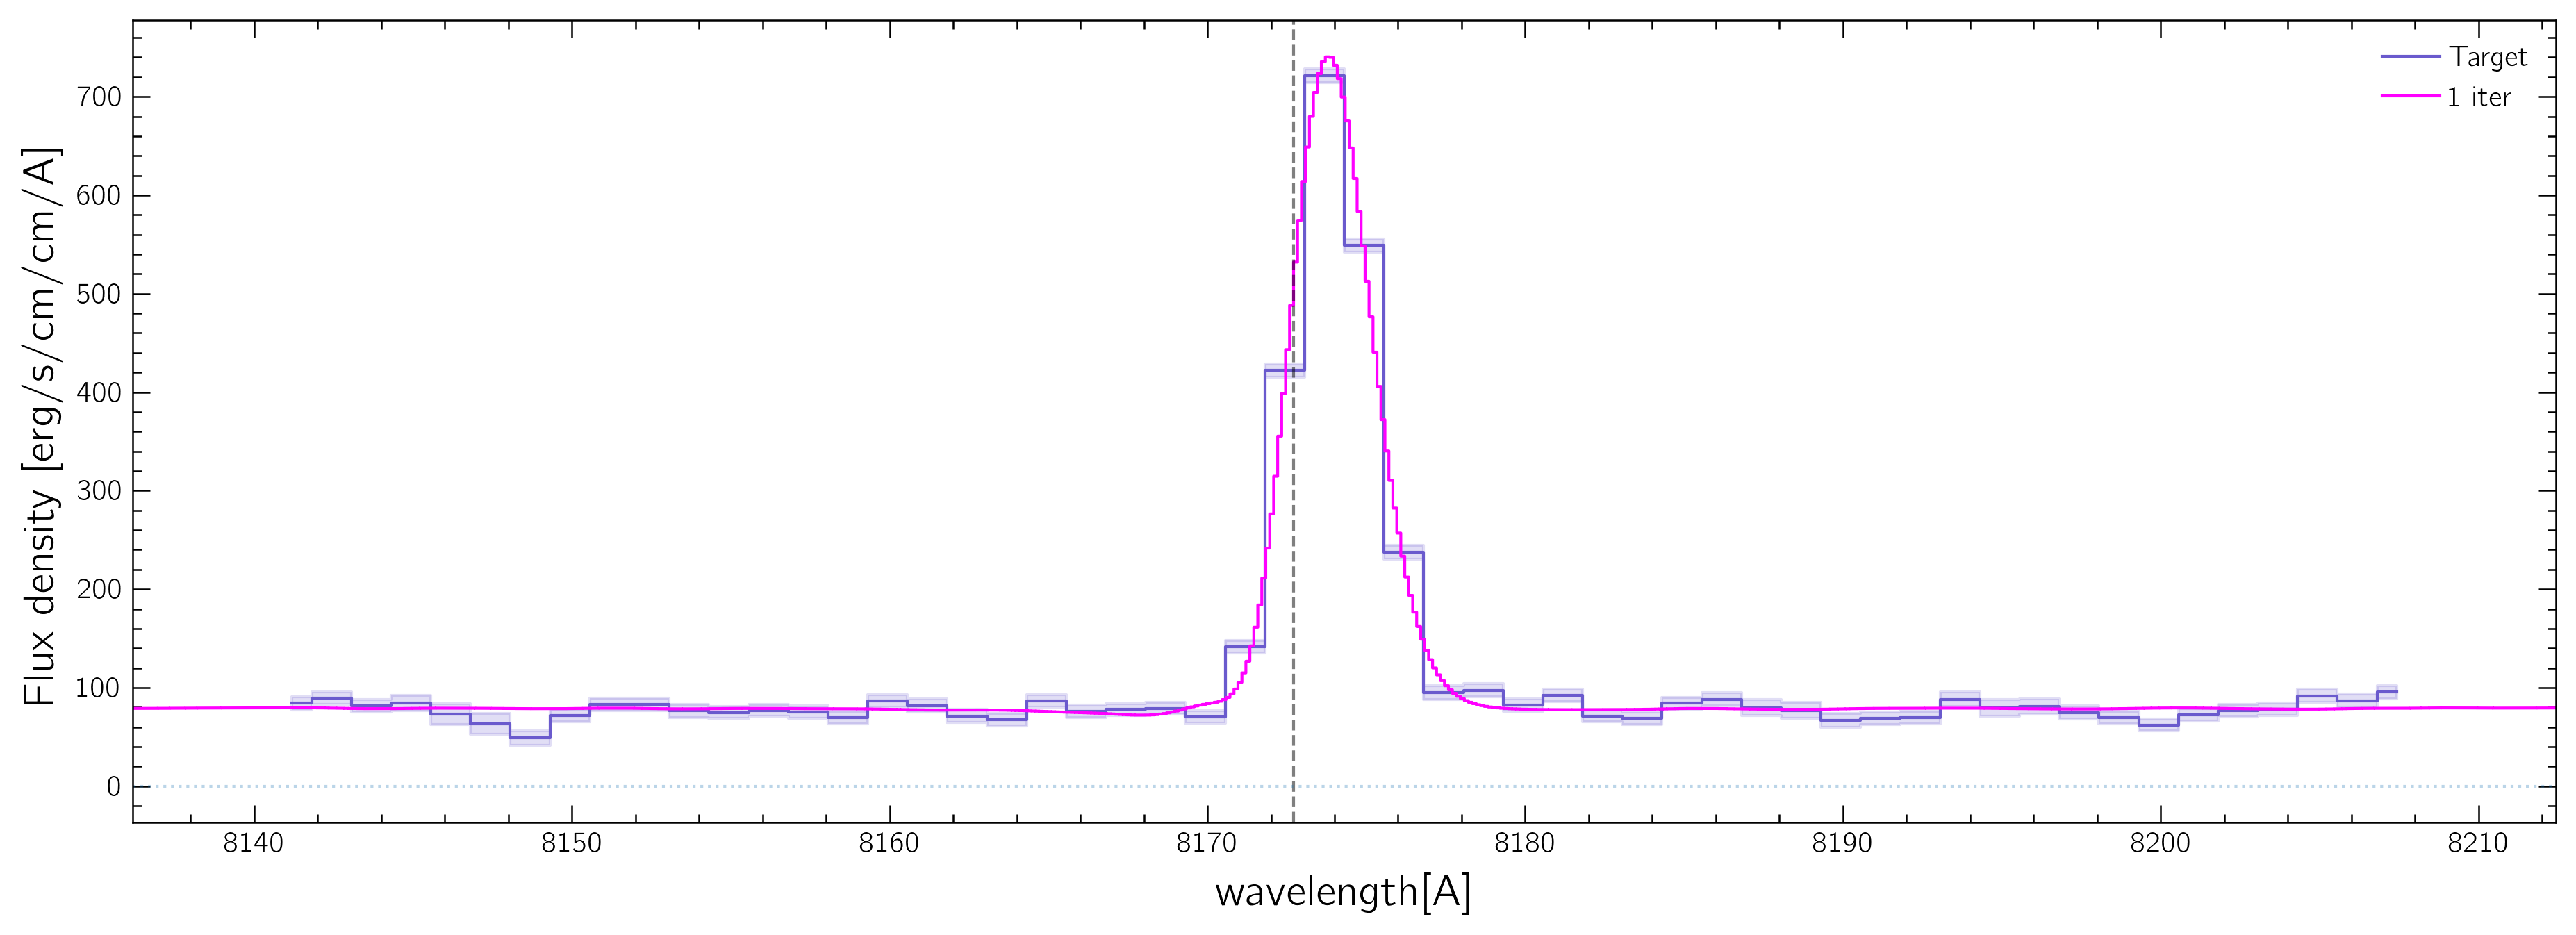

Done.
The measured redshift                                                     is 5.722798225841264
The measured expasion velocity                                            is 41.2379353473602
The measured logarithm of the HI column density                           is 18.039840511845338
The measured dust optical depth                                           is 0.9423984344705683
The measured logarithm of the intrinsic equivalent width                  is 0.9422214944490893
The measured intrinsic width                                              is 0.010160720976590055
Processing source SP8268 from cluster A2744 with zELDA
Generating spectrum...
Loading aperture spectrum for A2744 object SP8268...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:17<00:00,  5.67it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.37it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 14.20990407872602


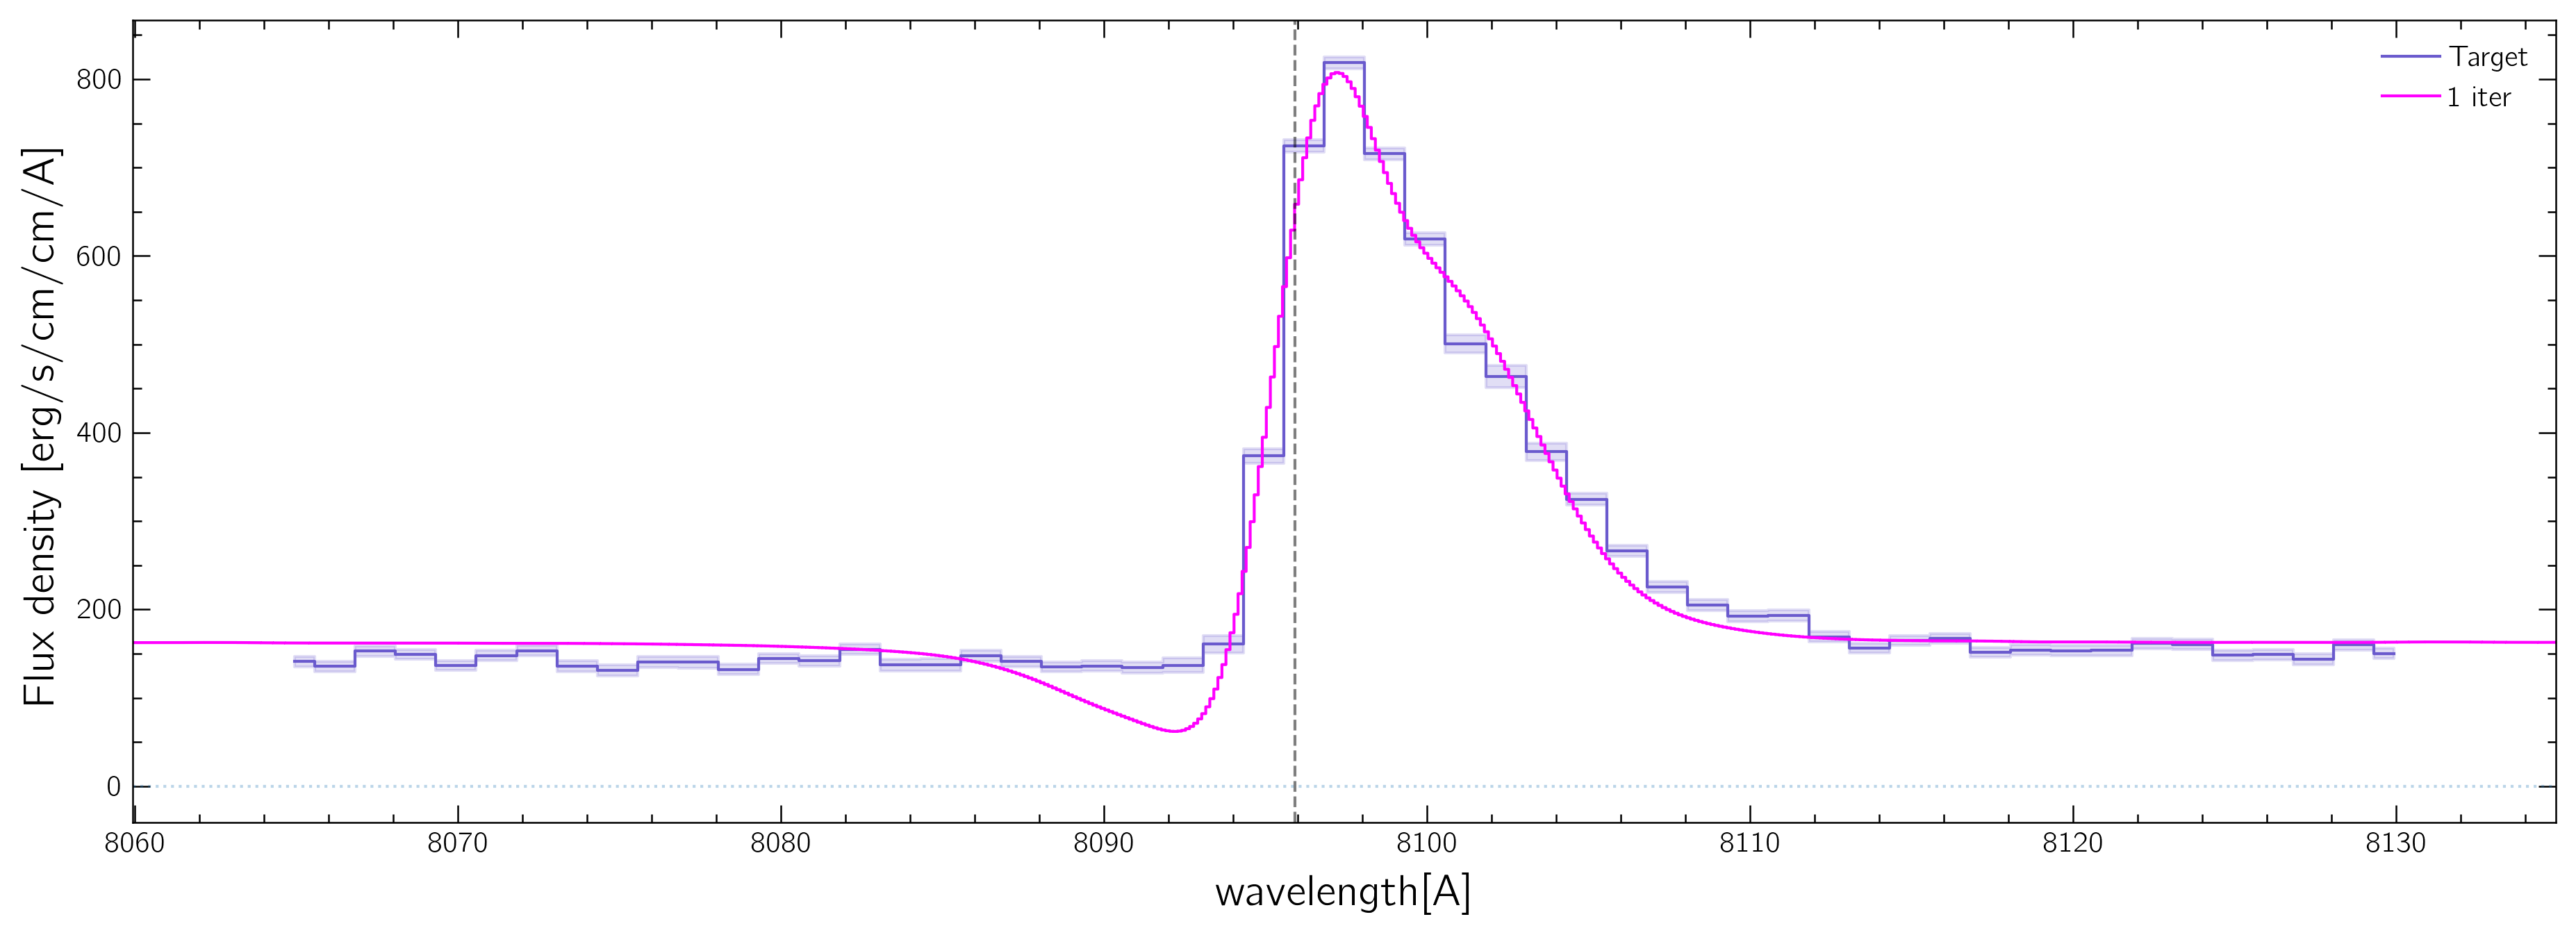

Done.
The measured redshift                                                     is 5.659621029460192
The measured expasion velocity                                            is 132.2642868501348
The measured logarithm of the HI column density                           is 18.806974391218812
The measured dust optical depth                                           is 0.0033652599961948087
The measured logarithm of the intrinsic equivalent width                  is 0.5892155456123681
The measured intrinsic width                                              is 0.05051242625789672
Processing source P4926 from cluster A2744 with zELDA
Generating spectrum...
Loading aperture spectrum for A2744 object P4926...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.99it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:25<00:00,  5.87it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 3.2660723352609953


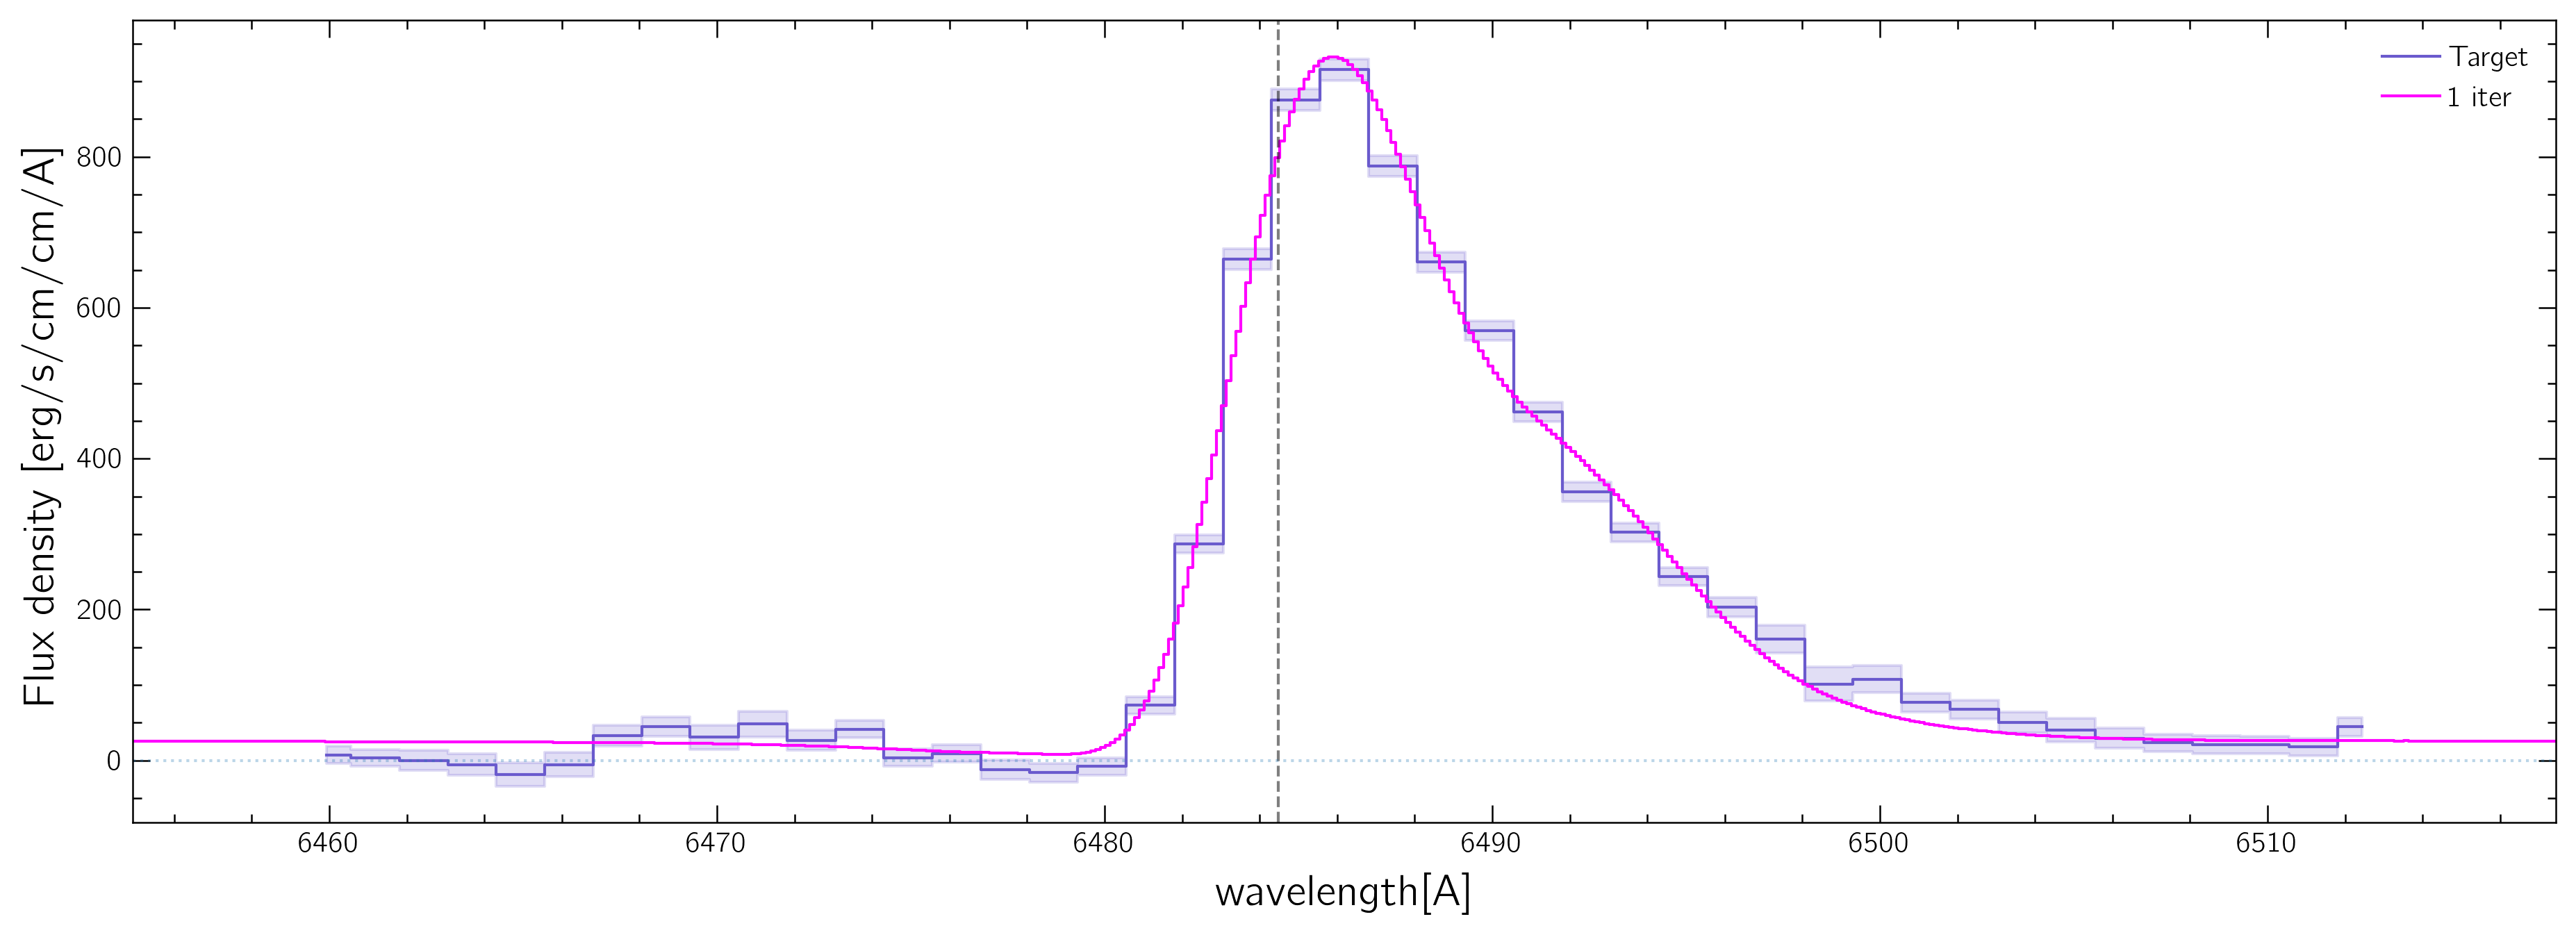

Done.
The measured redshift                                                     is 4.334072888971112
The measured expasion velocity                                            is 249.93493756255148
The measured logarithm of the HI column density                           is 19.224154975866732
The measured dust optical depth                                           is 0.051210862533900316
The measured logarithm of the intrinsic equivalent width                  is 1.7425564404715557
The measured intrinsic width                                              is 0.26397081491480107
Processing source P1200 from cluster MACS0416NE with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0416NE object P1200...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.06it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:21<00:00,  6.85it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 7.086437372812489


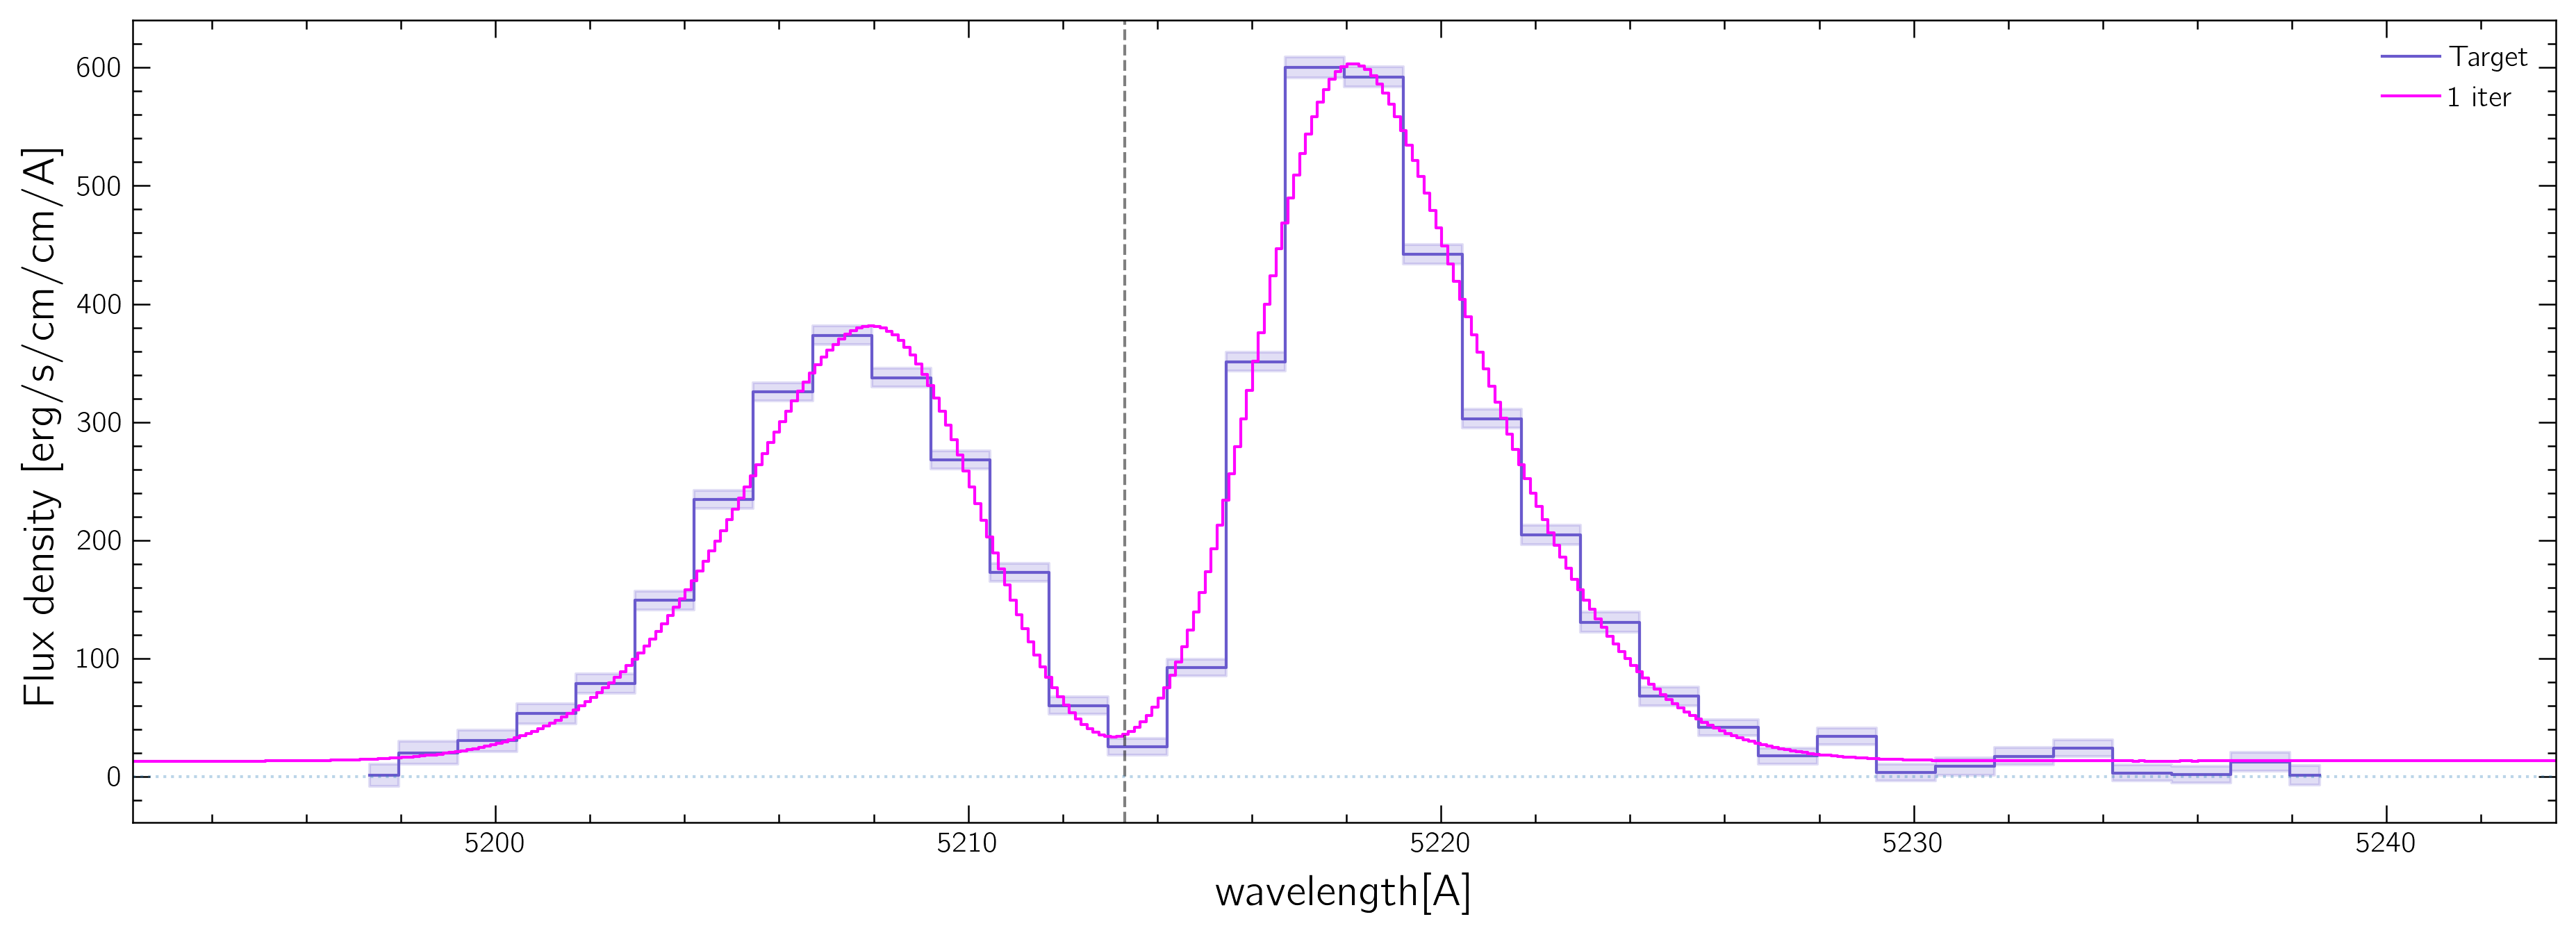

Done.
The measured redshift                                                     is 3.2884216603243406
The measured expasion velocity                                            is 10.636510214284733
The measured logarithm of the HI column density                           is 20.0022484899649
The measured dust optical depth                                           is 0.2643181836935758
The measured logarithm of the intrinsic equivalent width                  is 2.645361612213728
The measured intrinsic width                                              is 0.9438028291748847
Processing source P2861 from cluster MACS1206 with zELDA
Generating spectrum...
Loading aperture spectrum for MACS1206 object P2861...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.17it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.50it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 13.147589061373848


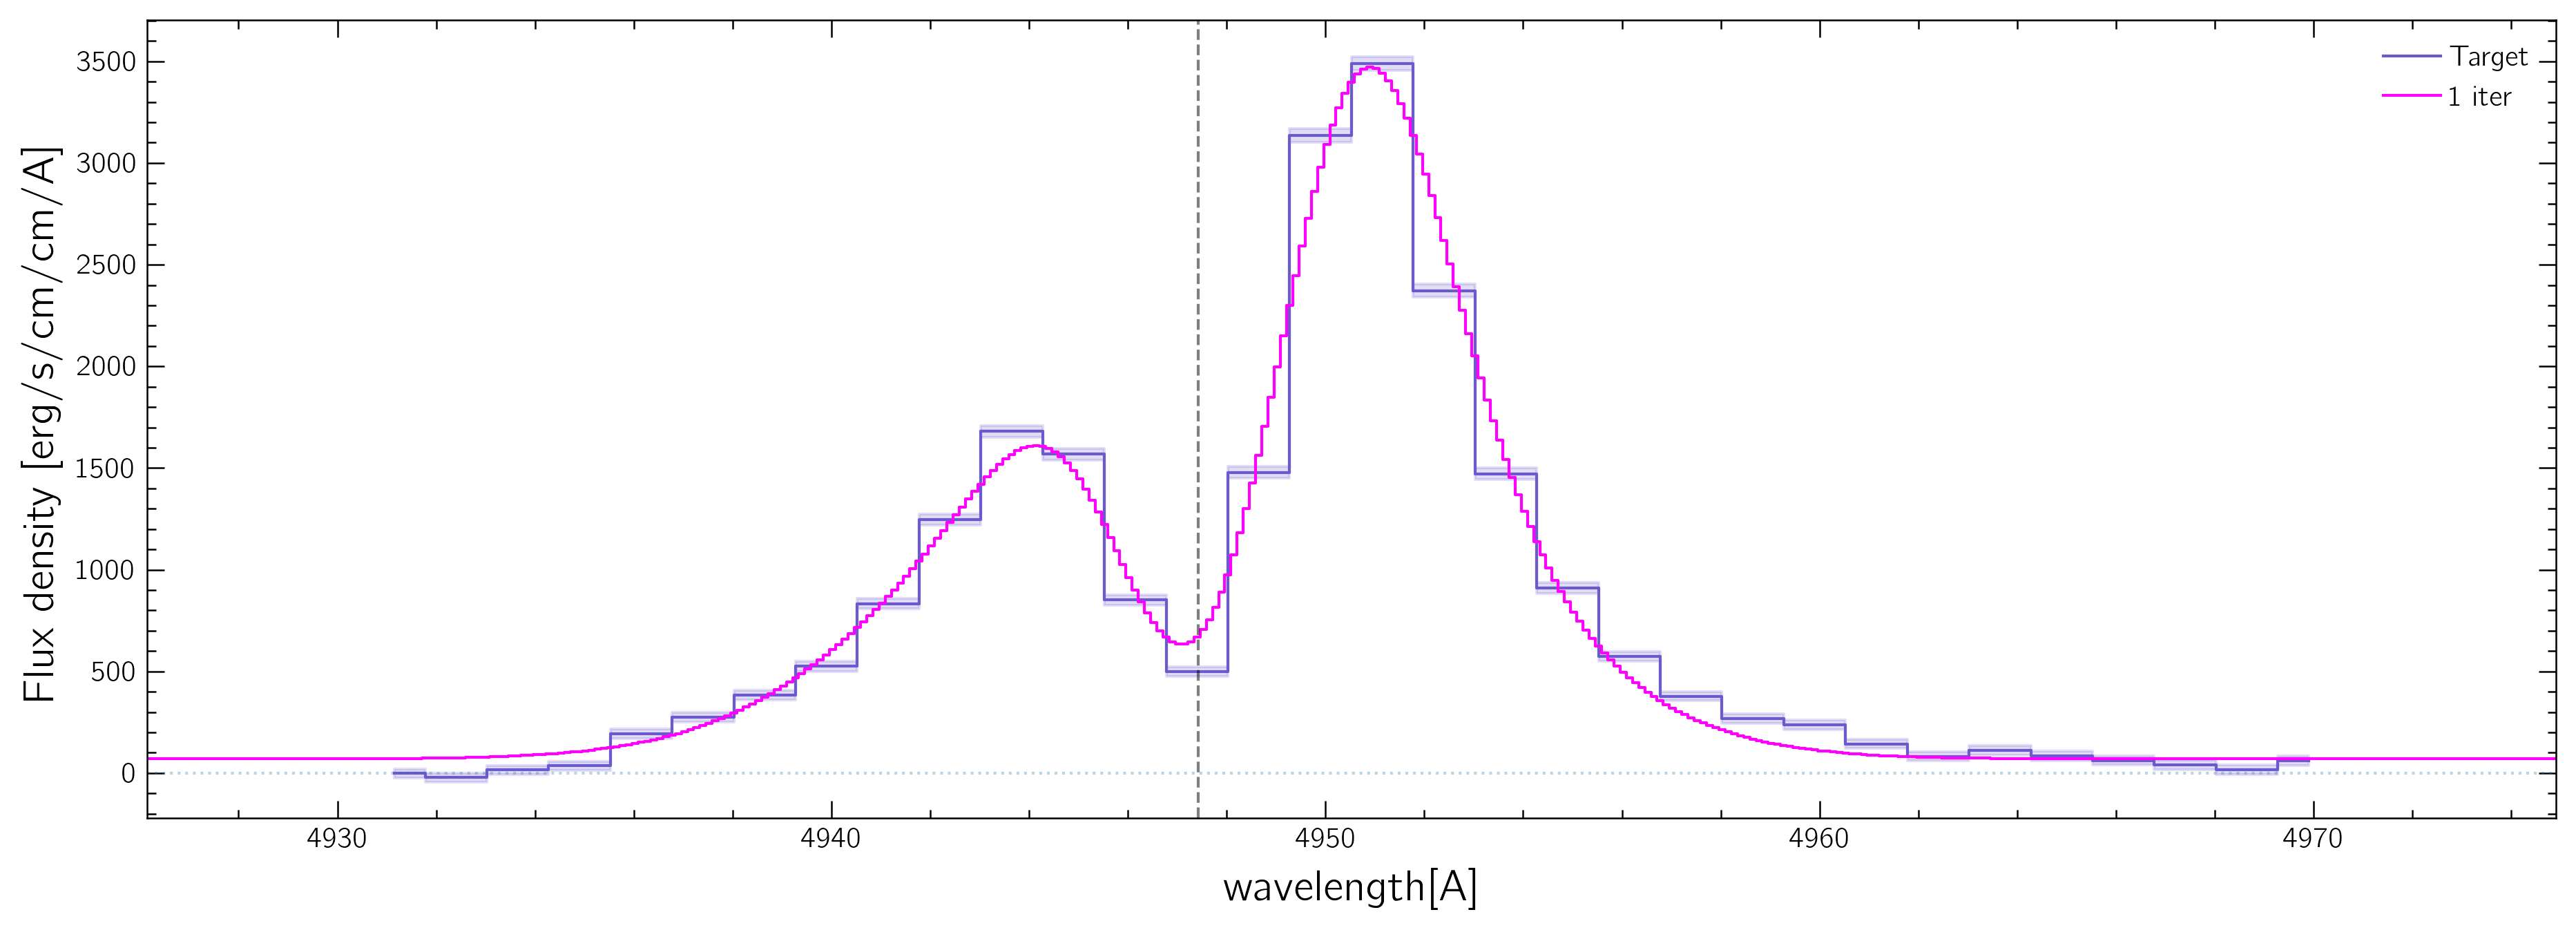

Done.
The measured redshift                                                     is 3.069712285852492
The measured expasion velocity                                            is 13.892246235385503
The measured logarithm of the HI column density                           is 19.749998441781
The measured dust optical depth                                           is 0.011592082816854985
The measured logarithm of the intrinsic equivalent width                  is 2.036619538294721
The measured intrinsic width                                              is 1.0445676513124547
Processing source SM63 from cluster SMACS2031 with zELDA
Generating spectrum...
Loading aperture spectrum for SMACS2031 object SM63...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.09it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:27<00:00,  5.42it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 2.2643368164677447


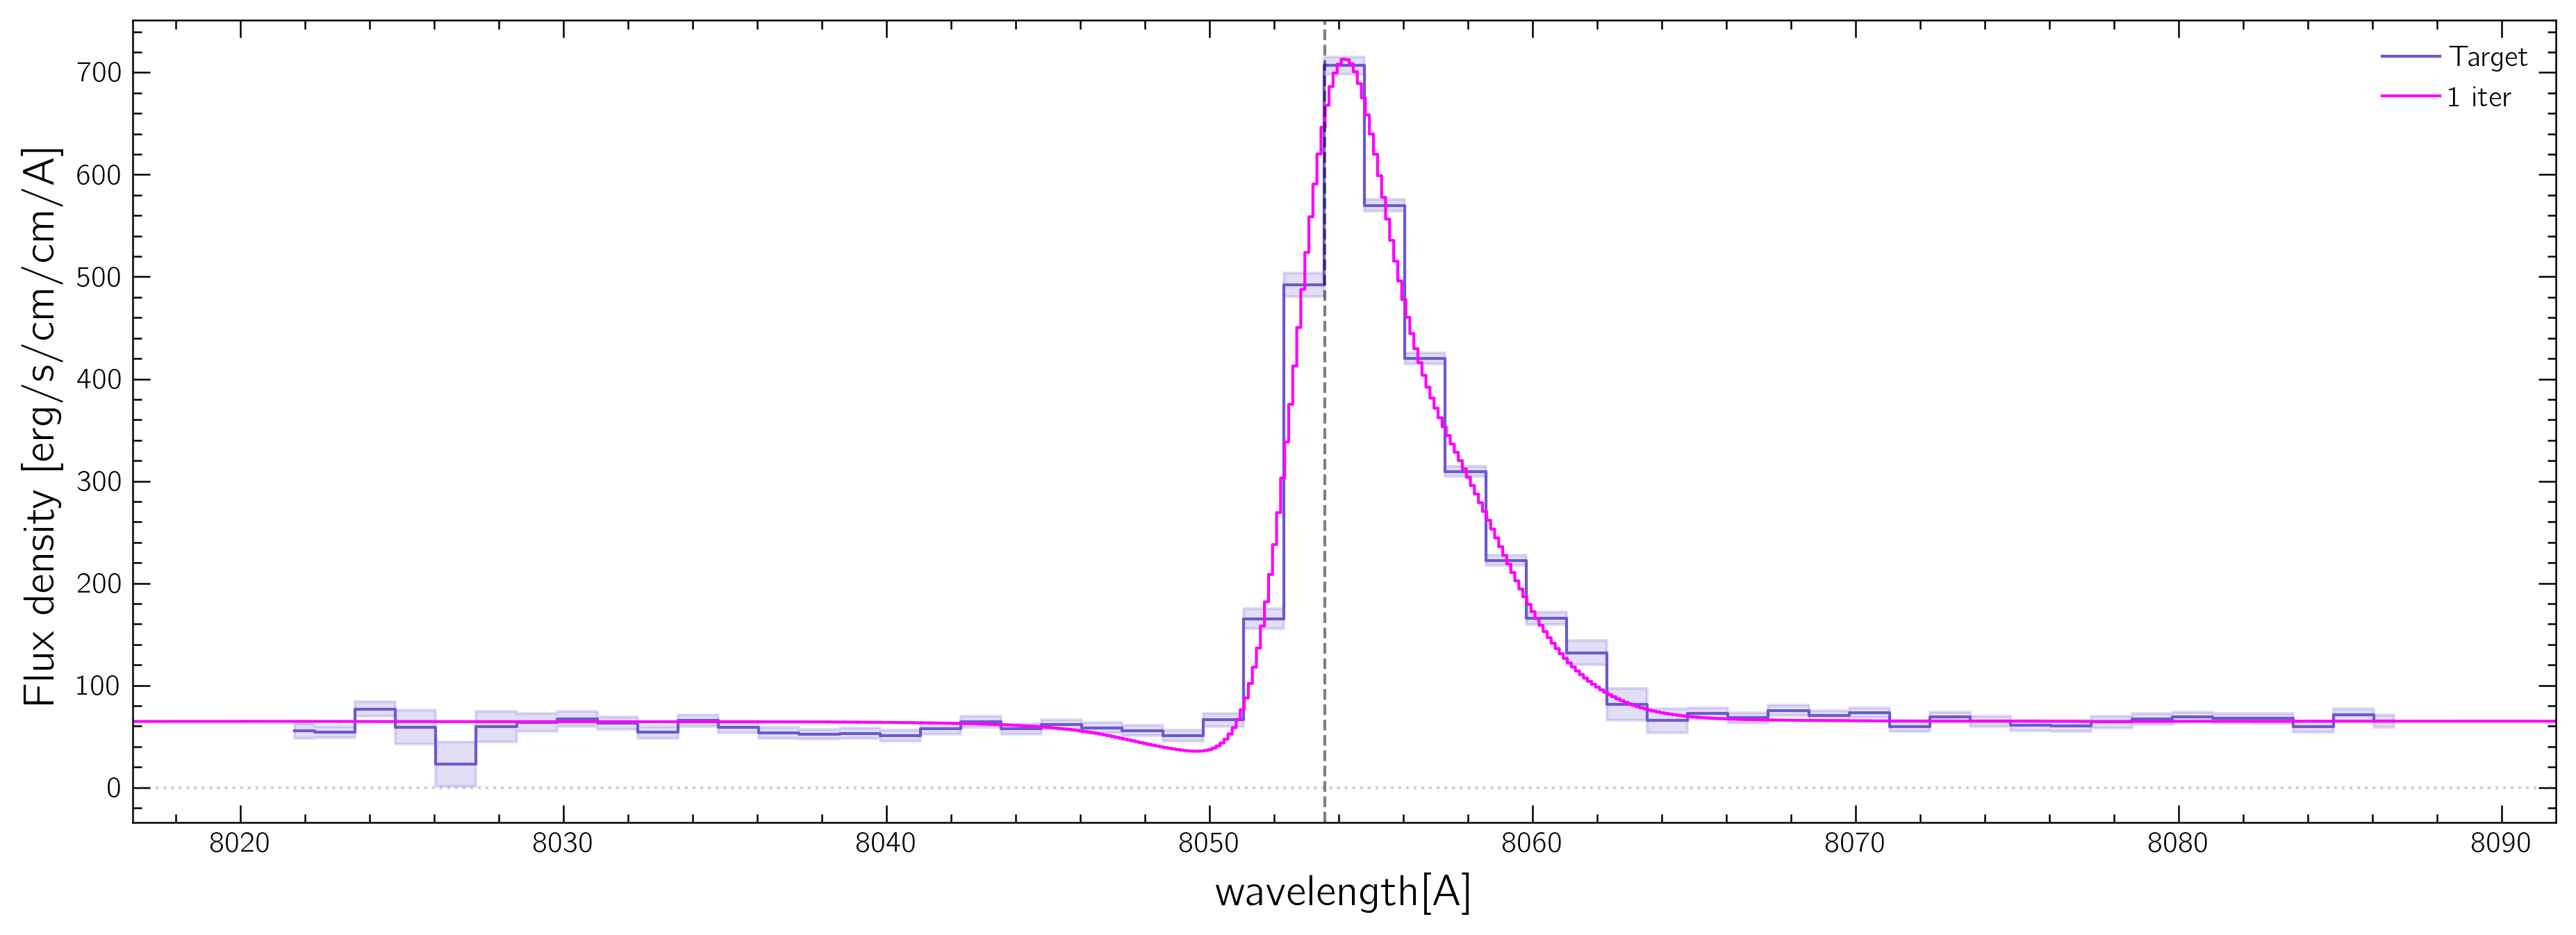

Done.
The measured redshift                                                     is 5.624803546290418
The measured expasion velocity                                            is 113.55083070752995
The measured logarithm of the HI column density                           is 18.408417691941384
The measured dust optical depth                                           is 0.005774608213696405
The measured logarithm of the intrinsic equivalent width                  is 0.870689900338506
The measured intrinsic width                                              is 0.035649449491120144
Processing source P477 from cluster MACS0257 with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0257 object P477...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.21it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:20<00:00,  7.36it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 7.53965938419696


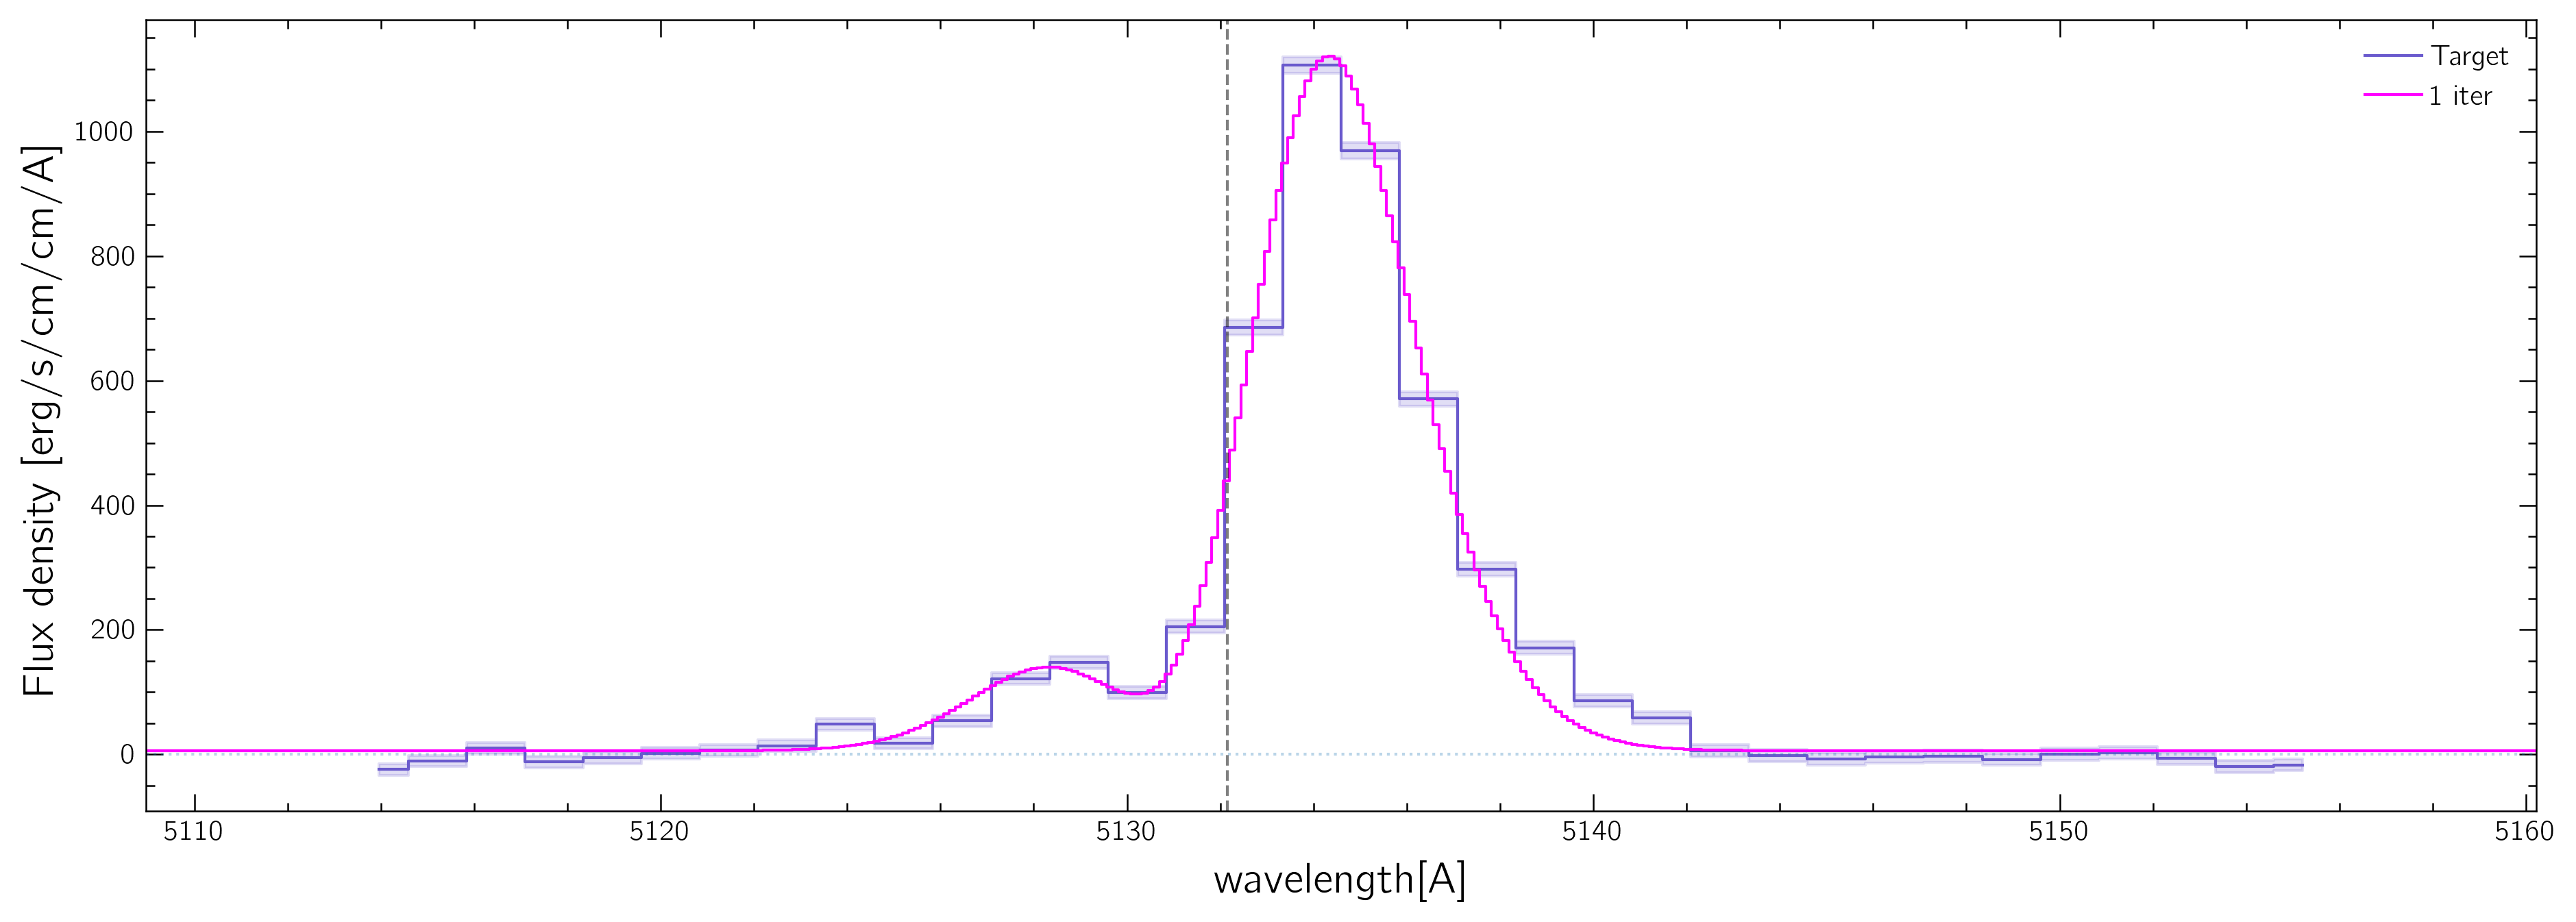

Done.
The measured redshift                                                     is 3.221669311613023
The measured expasion velocity                                            is 84.50955813312365
The measured logarithm of the HI column density                           is 18.994781628588868
The measured dust optical depth                                           is 0.9545497138301652
The measured logarithm of the intrinsic equivalent width                  is 2.8512779980961764
The measured intrinsic width                                              is 0.28988792896497706
Processing source P103 from cluster SMACS2131 with zELDA
Generating spectrum...
Loading aperture spectrum for SMACS2131 object P103...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.88it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:27<00:00,  5.47it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 5.4000801335908495


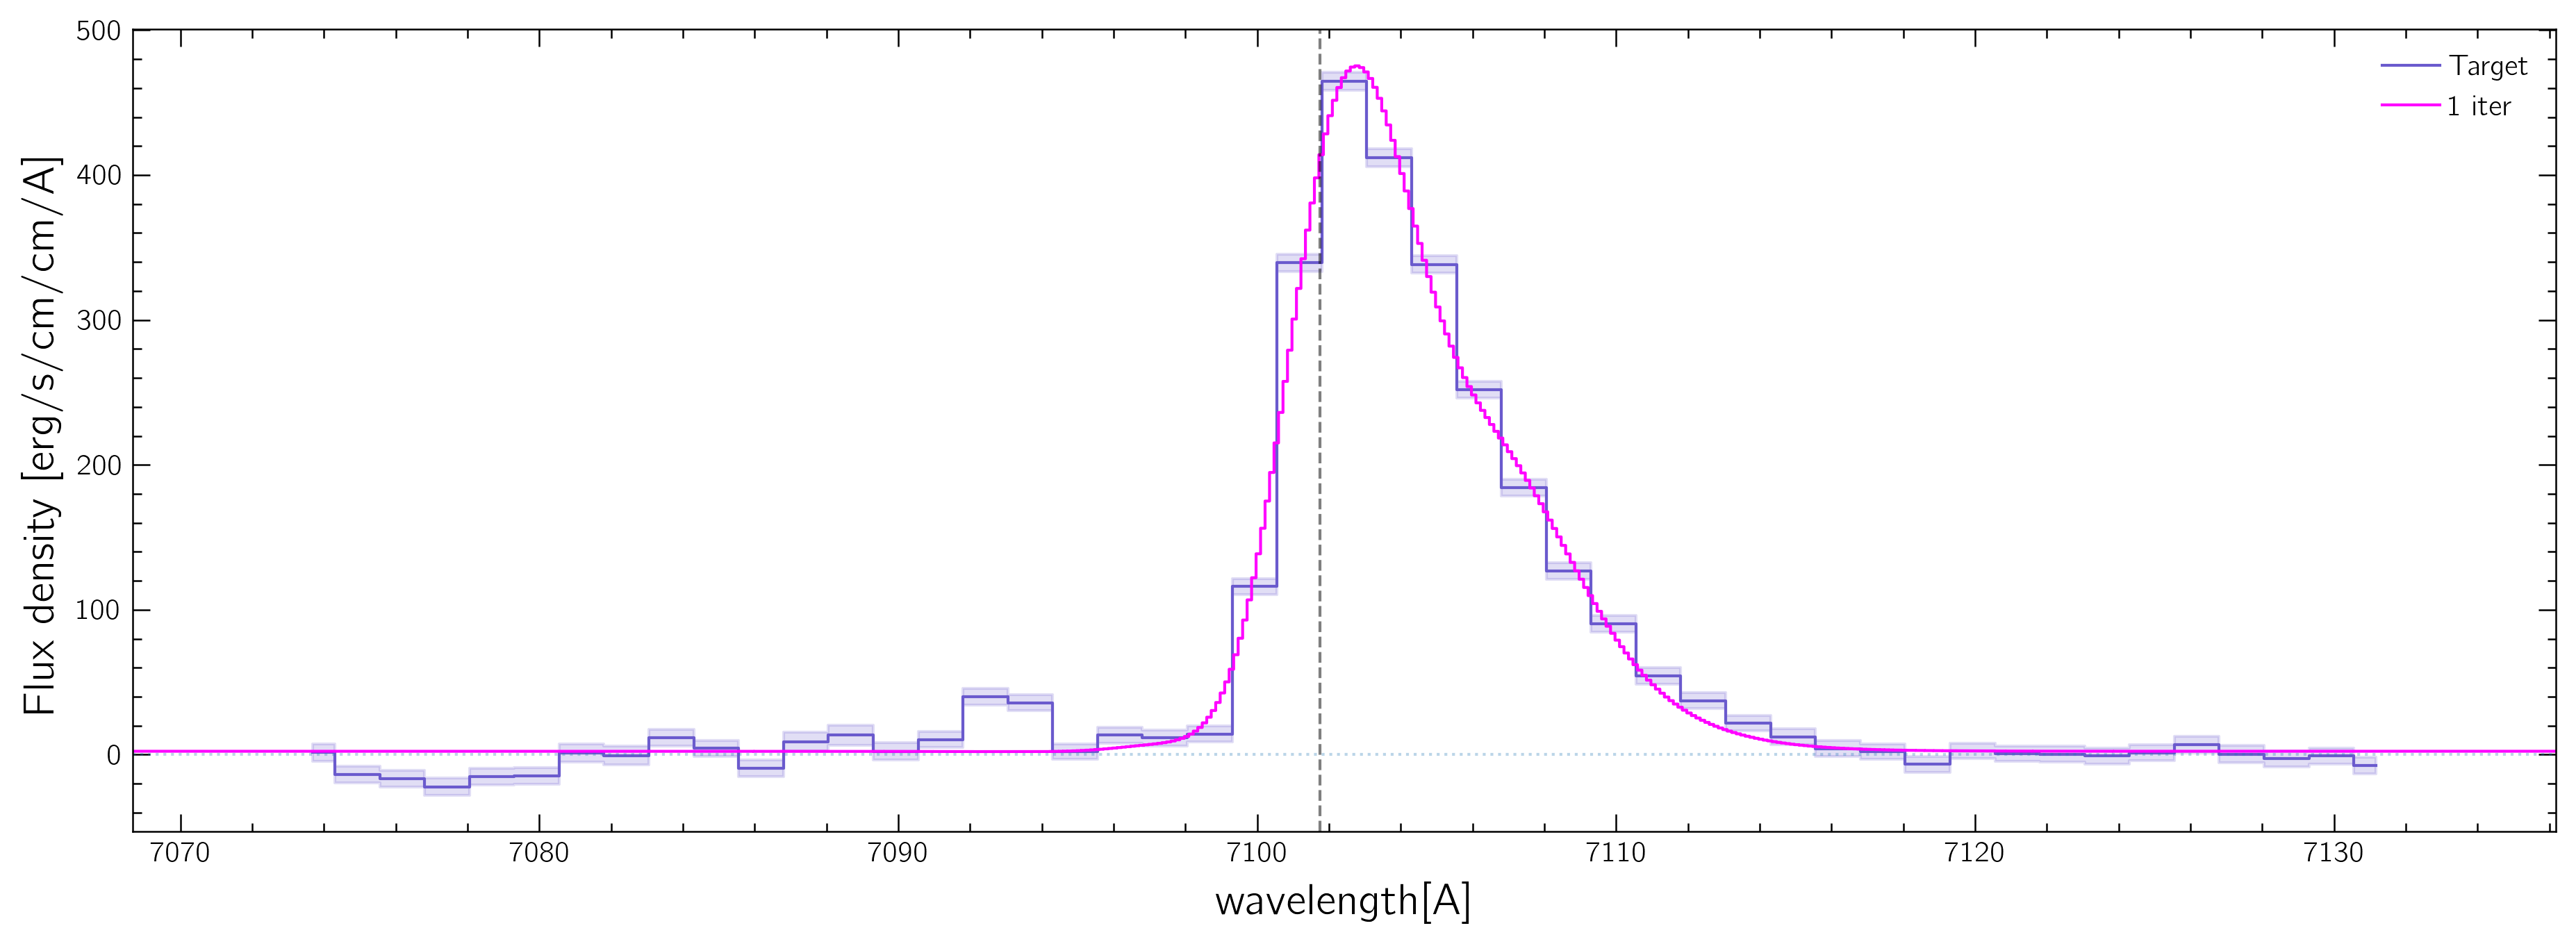

Done.
The measured redshift                                                     is 4.84184035740994
The measured expasion velocity                                            is 154.6164300925364
The measured logarithm of the HI column density                           is 18.798610519493913
The measured dust optical depth                                           is 0.0009966948693488362
The measured logarithm of the intrinsic equivalent width                  is 2.478153679273867
The measured intrinsic width                                              is 0.09383782316831245
Processing source SP1493 from cluster RXJ1347 with zELDA
Generating spectrum...
Loading aperture spectrum for RXJ1347 object SP1493...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.91it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.30it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
Genuinely high-dust fit over 95% confidence interval!
model reduced chi squared = 6.915480687494007


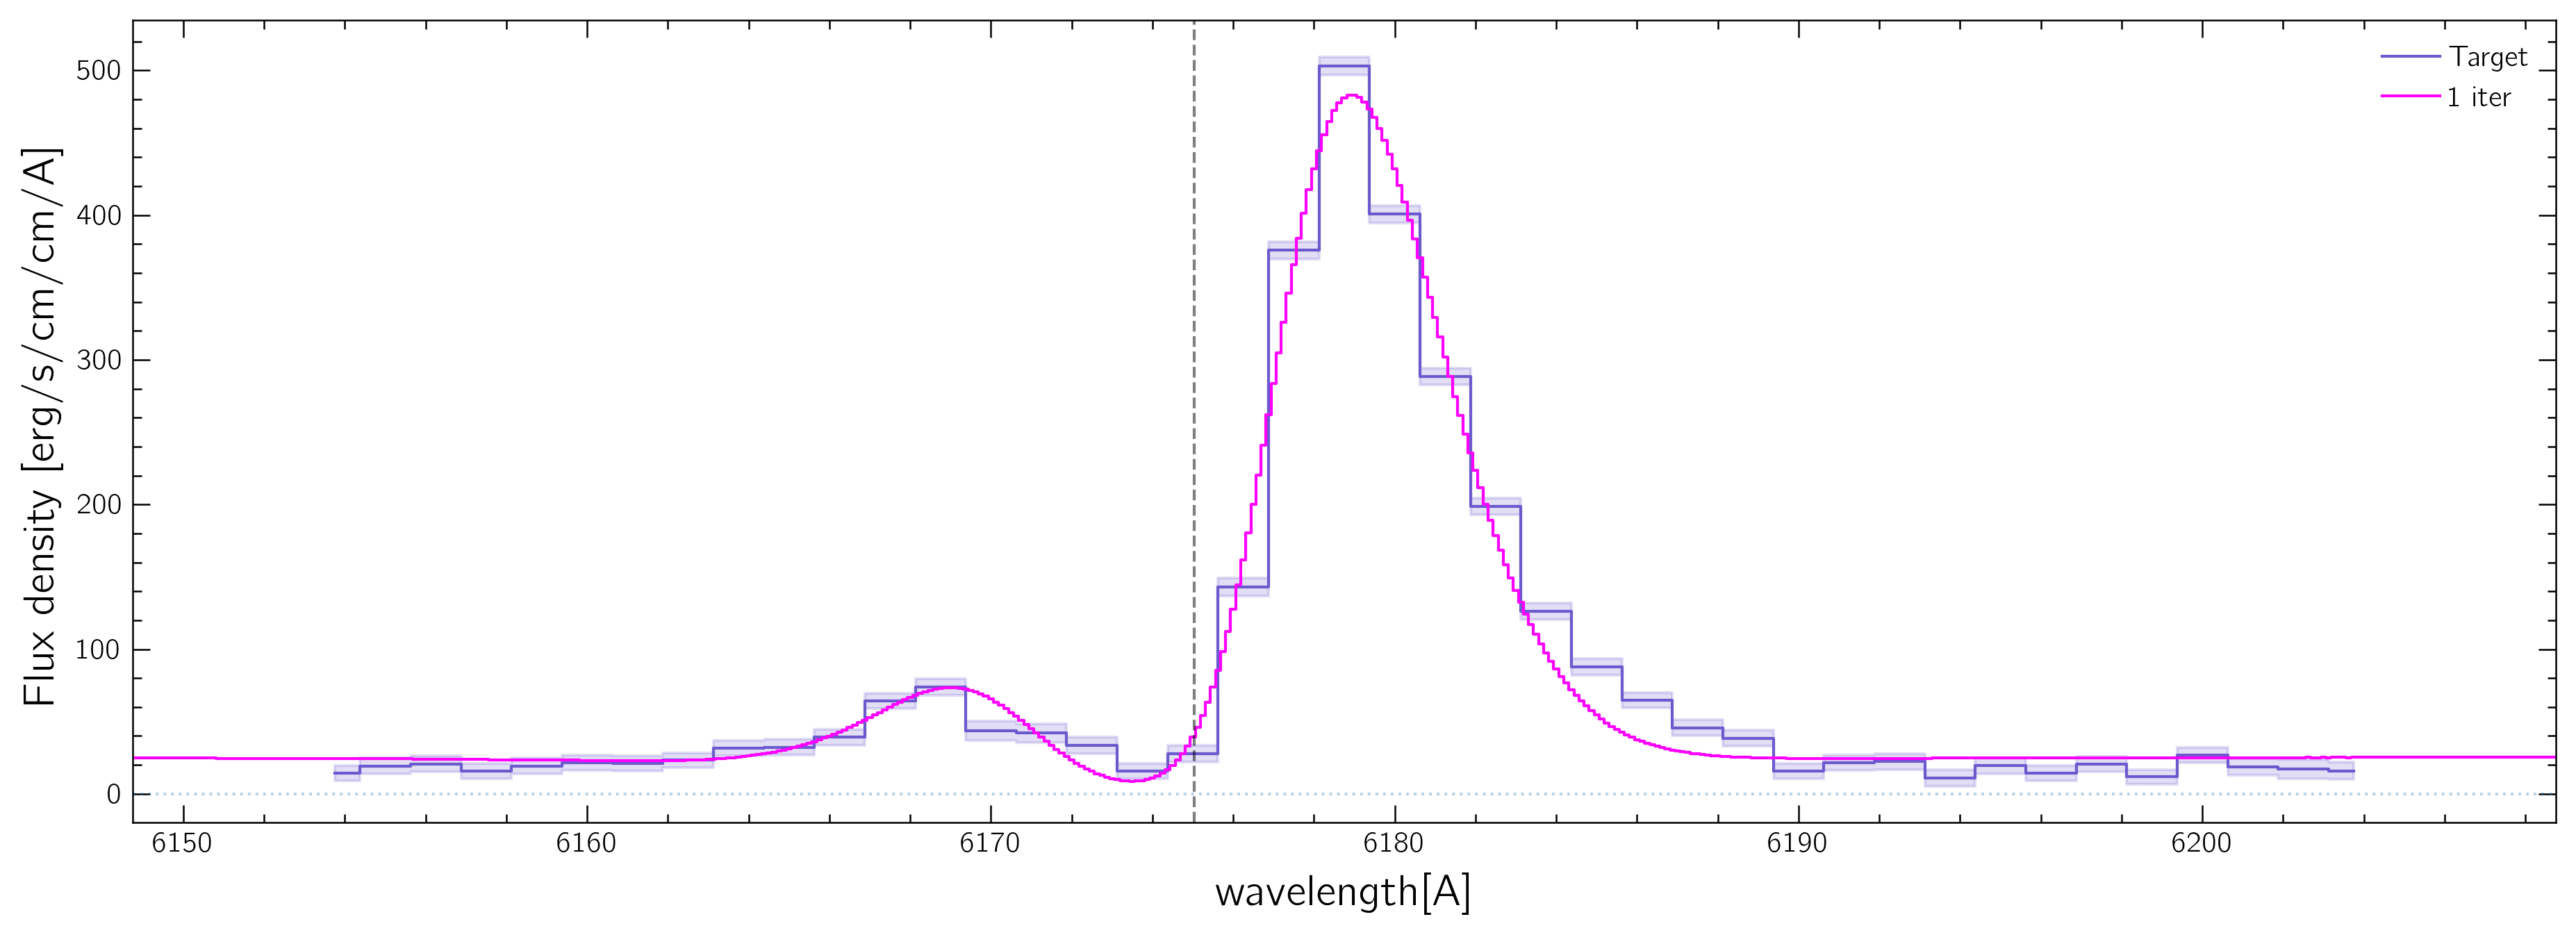

Done.
The measured redshift                                                     is 4.079524376845231
The measured expasion velocity                                            is 78.87866818796752
The measured logarithm of the HI column density                           is 19.49984586823046
The measured dust optical depth                                           is 0.9995810499711756
The measured logarithm of the intrinsic equivalent width                  is 1.9290934712984038
The measured intrinsic width                                              is 0.43647393027464265
Processing source SP594 from cluster MACS0416NE with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0416NE object SP594...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.90it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:15<00:00,  9.70it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 9.085967786240019


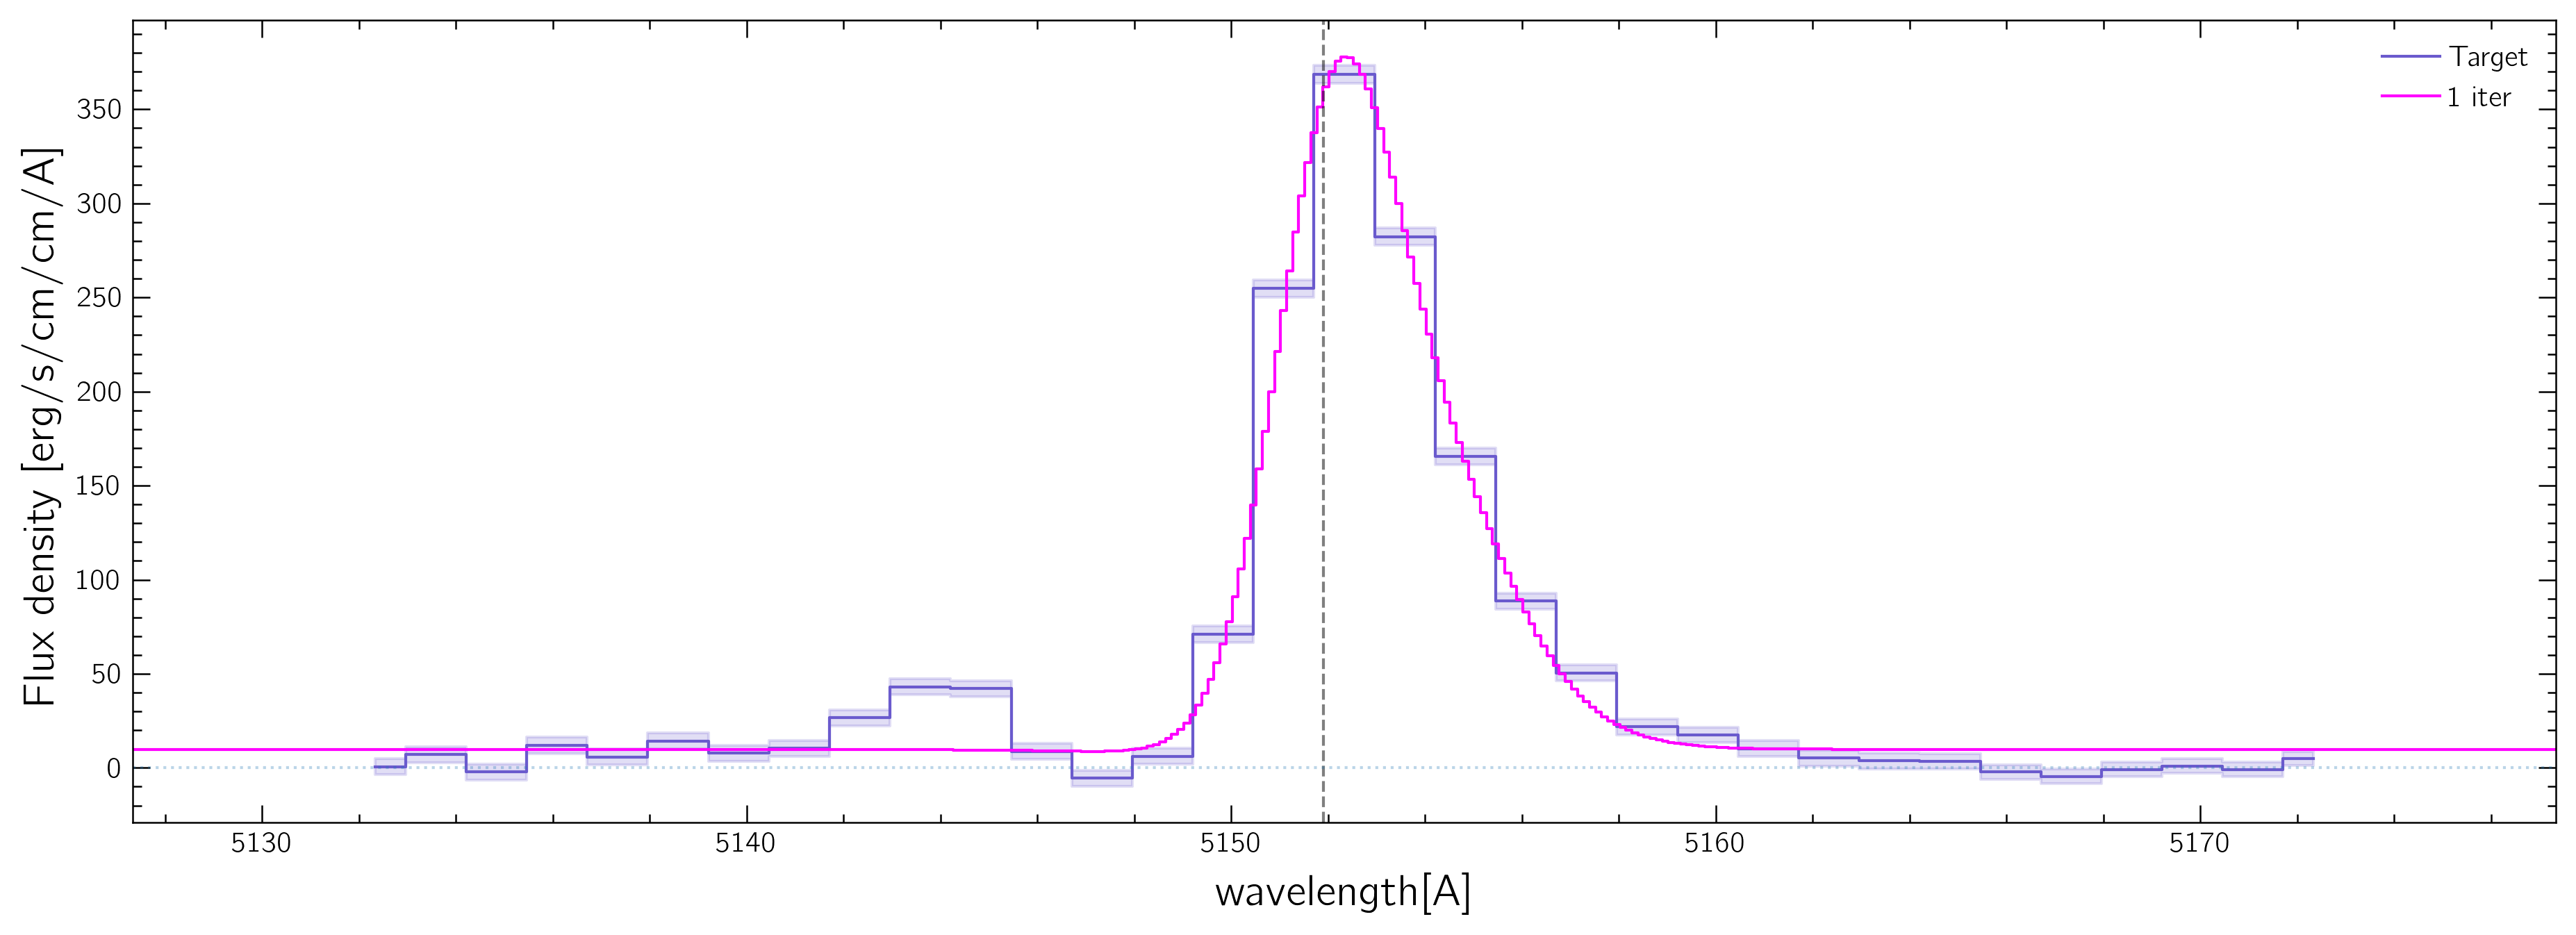

Done.
The measured redshift                                                     is 3.2379051482159715
The measured expasion velocity                                            is 109.14264022157084
The measured logarithm of the HI column density                           is 18.37394429848452
The measured dust optical depth                                           is 0.0002126939747848941
The measured logarithm of the intrinsic equivalent width                  is 1.5908654492768957
The measured intrinsic width                                              is 0.026376761012510186
Processing source P617 from cluster MACS0416NE with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0416NE object P617...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.10it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.39it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
Genuinely high-dust fit over 95% confidence interval!
model reduced chi squared = 3.0483531444811733


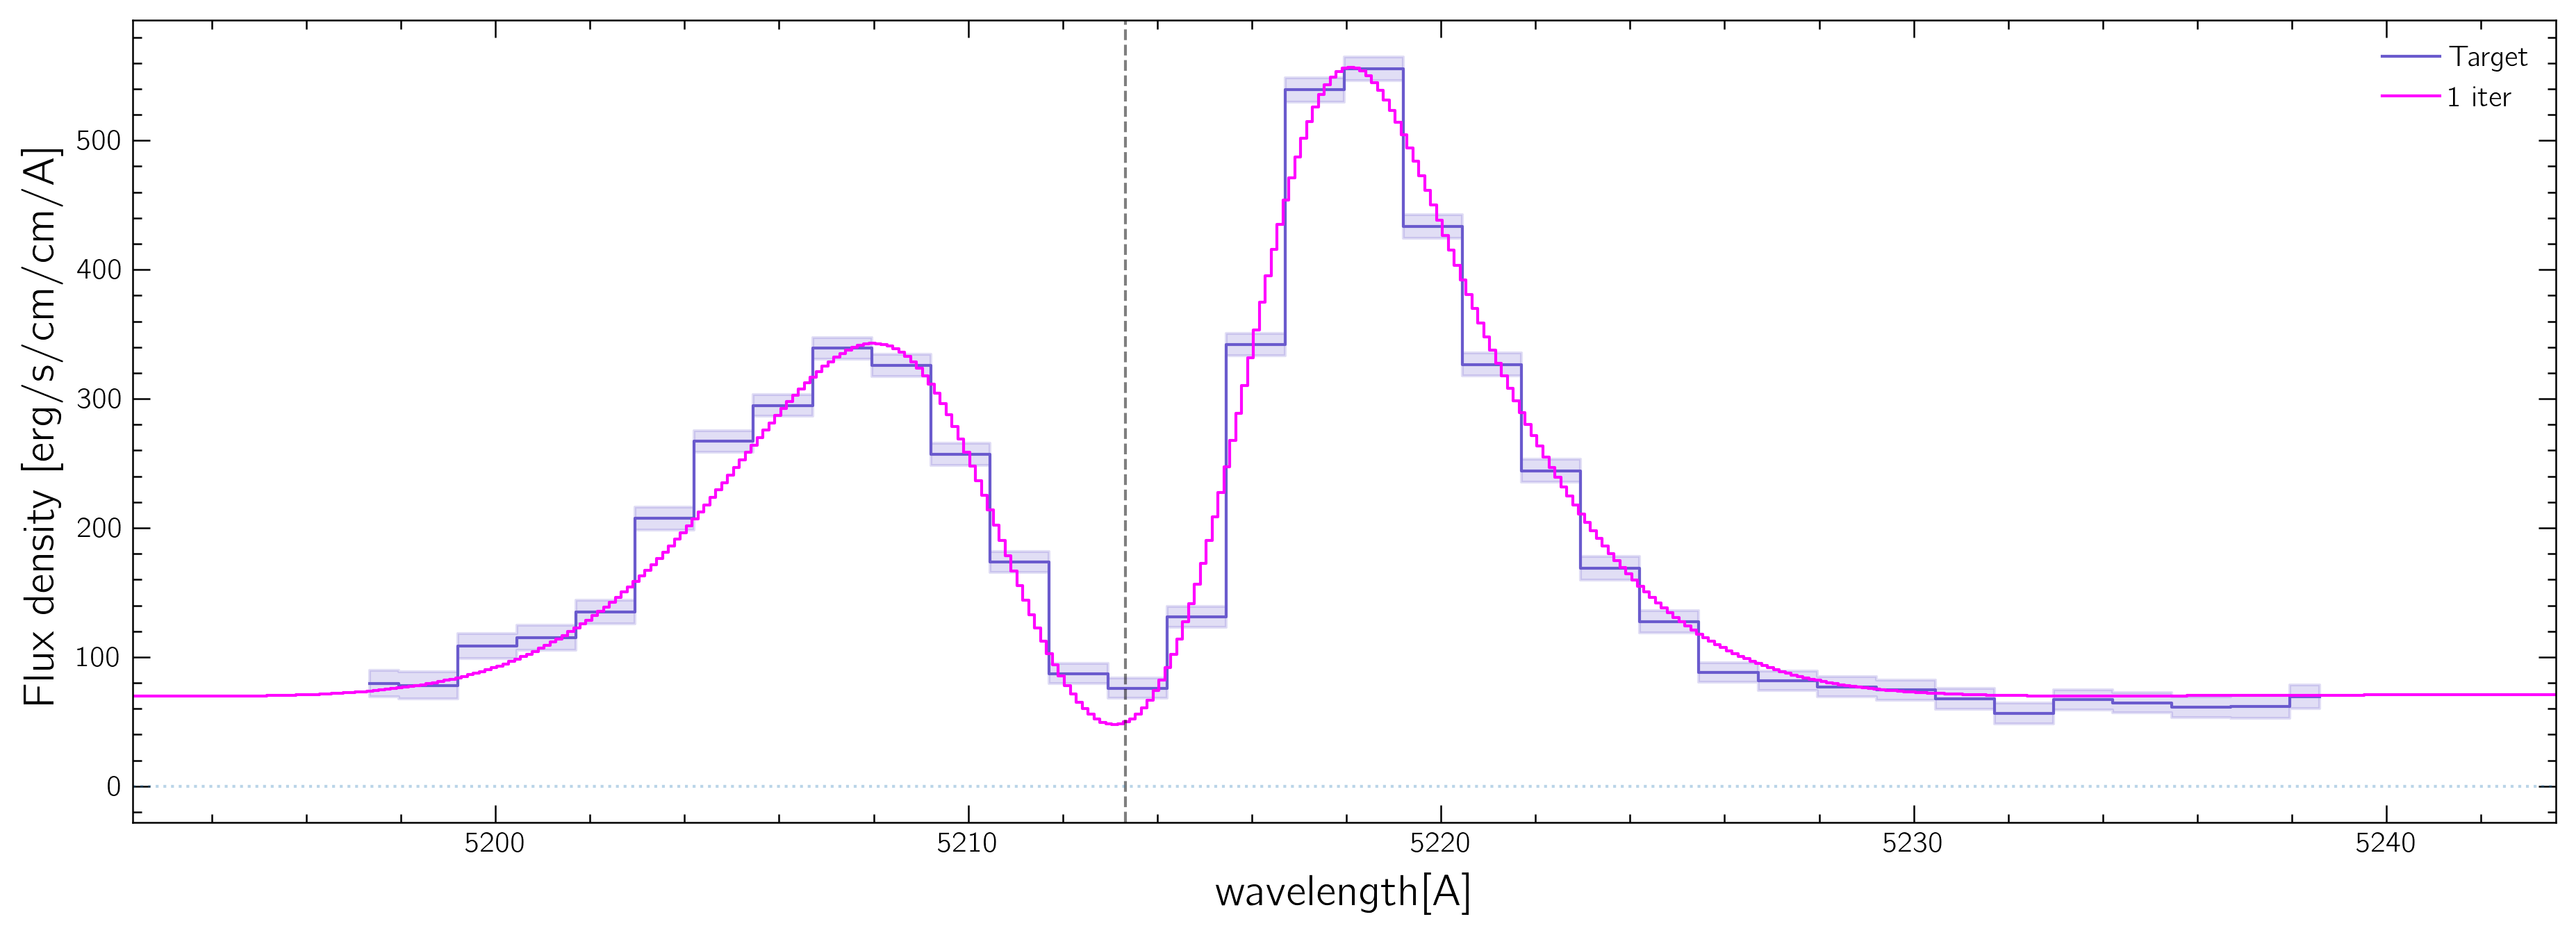

Done.
The measured redshift                                                     is 3.2884379200204714
The measured expasion velocity                                            is 10.784209457584534
The measured logarithm of the HI column density                           is 20.000020144415767
The measured dust optical depth                                           is 0.14087018456190667
The measured logarithm of the intrinsic equivalent width                  is 1.6618859601717832
The measured intrinsic width                                              is 1.301237331764827
Processing source SP63 from cluster SMACS2031 with zELDA
Generating spectrum...
Loading aperture spectrum for SMACS2031 object SP63...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.88it/s]


Running main MCMC


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:23<00:00,  6.33it/s]


Done
Done. Processing results...
chains_shape =  (150, 100, 6)
log_probs_shape =  (150, 100)
flat_samples shape =  (15000, 6)
flat_log_prob shape =  (15000,)
model reduced chi squared = 2.4028077300729427


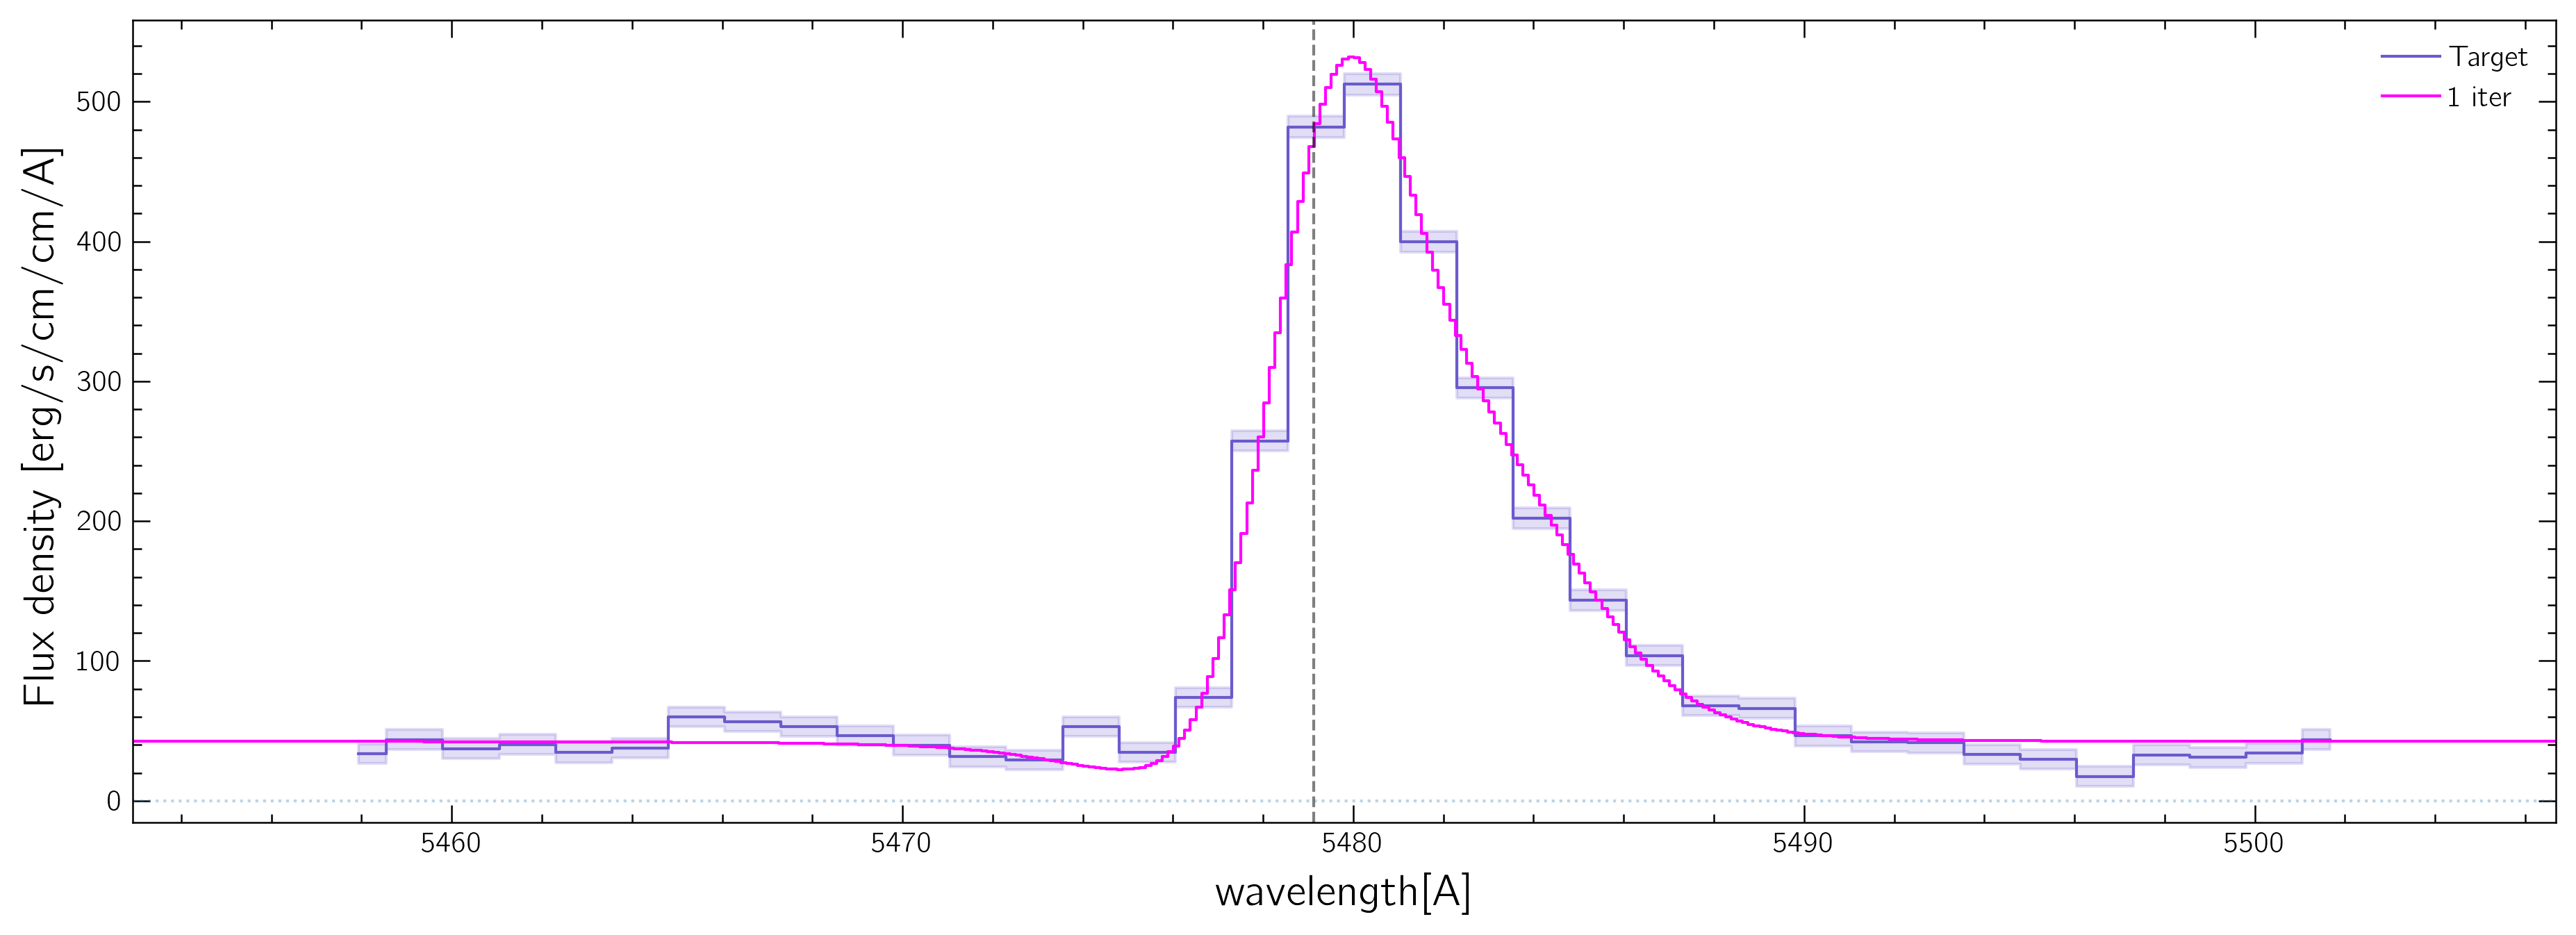

Done.
The measured redshift                                                     is 3.5070861934598843
The measured expasion velocity                                            is 167.14531013694642
The measured logarithm of the HI column density                           is 18.772577972616585
The measured dust optical depth                                           is 0.0003293921670727734
The measured logarithm of the intrinsic equivalent width                  is 1.1388431793996396
The measured intrinsic width                                              is 0.09259607559381232
Processing source P5114 from cluster MACS0416S with zELDA
Generating spectrum...
Loading aperture spectrum for MACS0416S object P5114...
Initializing MCMC...


/home/james/anaconda3/envs/zelda_restored/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 0.22.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Running MCMC...
defining samples
burning in


 70%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                             | 70/100 [00:10<00:04,  7.09it/s]

In [ ]:
# USE FULL MCMC FITTING WITH ZELDA
from tangelo import spectroscopy as tgspec
import time

# Generate table columns
if 'Z_ZELDA' not in megatab.colnames:
    megatab['RCHSQ_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['Z_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['Z_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['Z_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['Z_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan
    megatab['VEXP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['VEXP_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['VEXP_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['VEXP_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGN_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGN_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGN_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGN_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan
    megatab['TDUST_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['TDUST_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['TDUST_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['TDUST_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGIEW_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGIEW_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGIEW_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['LOGIEW_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan
    megatab['WINT_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['WINT_ERRM_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['WINT_ERRP_ZELDA'] = np.zeros(len(megatab)) * np.nan
    megatab['WINT_ZELDA_ML'] = np.zeros(len(megatab)) * np.nan

# What geometry to use here?
Geometry = 'Thin_Shell_Cont'

tests = [
    "7681",
    "00080",
    "5399",
    "0001292",
    "3328",
    "5624",
    "2159",
    "10503",
    "7737",
    "0004770",
    "375",
    "3031",
    "8683",
    "653",
    "484",
    "632",
    "470",
    "0005393",
    "305",
    "573",
    "3035",
    "0001050",
    "869",
    "8253",
    "7858",
    "6228"
]

megatab_writename = f"./megatables/lae_megatab_flagged_cpts_refit_zeldamcmc_{SPEC_TYPE}.fits"

import signal

# 1. Define a custom exception for the timeout
class TimeoutException(Exception):
    pass

# 2. Define the signal handler
def signal_handler(signum, frame):
    raise TimeoutException("Iteration timed out")

# 3. Register the signal handler
signal.signal(signal.SIGALRM, signal_handler)

# 4. Implement the loop with a try...except block
timeout_seconds = 180 # Set your desired timeout

for i, row in enumerate(megatab):
#     if row['iden'] not in tests:
#         continue
    if row['Z_ZELDA'] > 0:
        continue
    signal.alarm(timeout_seconds) # Set the alarm for the current iteration
    print(f"Processing source {row['iden']} from cluster {row['CLUSTER']} with zELDA")

    try:
        # Generate spectrum
        print(f"Generating spectrum...")
        w_Arr, f_Arr, s_Arr = tgspec.get_line_spec(row, line='LYALPHA', width=5.0, rest=True, spec_source=SPEC_SOURCE,
                                                   spec_type=SPEC_TYPE)

        # Normalise the spectrum so that total Lyman alpha flux = 1
        f_Arr_n = f_Arr / np.nansum([row['FLUXR'], row['FLUXB']])
        s_Arr_n = s_Arr / np.nansum([row['FLUXR'], row['FLUXB']])

        # Get peak SNR
        peak = row['AMPR']
        noise = row['AMPR_ERR']
        PNR_t  = peak / noise # Signal to noise ratio of the maximum of the line.

        # Get LSF FWHM and pixel scale in Angstroms
        FWHM_t = tgspec.muse_lsf_fwhm_poly(row['LPEAKR'])  # Full width half maximum diluting the line. Mimics finite resolution. [A]
        PIX_t  = 1.25  # Wavelength binning of the line. [A]
    
        # MCMC initialization
        N_walkers = 100 # Number of walkers
        N_burn    = 100 # Number of steps to burn-in
        N_steps   = 150 # Number of steps to run after burning-in
        MODE      = 'DNN' #use NN to initialize the walkers. Can change to PSO if not working.
        print(f"Initializing MCMC...")
        log_V_in, log_N_in, log_t_in, log_E_in, \
            W_in, z_in, Best = Lya.MCMC_get_region_6D(MODE, w_Arr, f_Arr_n, 
                                                        s_Arr_n, FWHM_t, PIX_t, 
                                                        LyaRT_Grid, Geometry) #gets regions to spawn walkers. 
                                                                                #(NOT PRIORS) You can manually set also.

        print(f"Running MCMC...")
        # Perform MCMC
        sampler = Lya.MCMC_Analysis_sampler_5(w_Arr, f_Arr_n, s_Arr_n, FWHM_t, 
                                              N_walkers, N_burn, N_steps, Geometry,
                                              LyaRT_Grid, z_in = z_in, log_V_in = log_V_in,
                                              log_N_in = log_N_in, log_t_in = log_t_in, 
                                              log_E_in = log_E_in, W_in = W_in)

        print(f"Done. Processing results...")

    
        # Get MCMC results
        Q_Arr = [2.5, 50, 97.5] # You can add more percentiles here, like 95
        perc_matrix_sol, flat_samples = Lya.get_solutions_from_sampler(sampler, N_walkers, N_burn, N_steps, Q_Arr)

        # redshift:
        z_16     =     perc_matrix_sol[ 3 , 0 ] # corresponds to Q_Arr[0]
        z_50     =     perc_matrix_sol[ 3 , 1 ] # corresponds to Q_Arr[1]
        z_84     =     perc_matrix_sol[ 3 , 2 ] # corresponds to Q_Arr[2]
        # Expansion velocity.
        V_16     = 10**perc_matrix_sol[ 0 , 0 ]
        V_50     = 10**perc_matrix_sol[ 0 , 1 ]
        V_84     = 10**perc_matrix_sol[ 0 , 2 ]
        # dust optical depth.
        t_16     = 10**perc_matrix_sol[ 2 , 0 ]
        t_50     = 10**perc_matrix_sol[ 2 , 1 ]
        t_84     = 10**perc_matrix_sol[ 2 , 2 ]
        # Intrinsic width.
        W_16     =     perc_matrix_sol[ 5 , 0 ]
        W_50     =     perc_matrix_sol[ 5 , 1 ]
        W_84     =     perc_matrix_sol[ 5 , 2 ]
        # Logarithmic of the intrinsic equivalent width.
        log_E_16 =     perc_matrix_sol[ 4 , 0 ]
        log_E_50 =     perc_matrix_sol[ 4 , 1 ]
        log_E_84 =     perc_matrix_sol[ 4 , 2 ]
        # Logarithmic of the HI column density.
        log_N_16 =     perc_matrix_sol[ 1 , 0 ]
        log_N_50 =     perc_matrix_sol[ 1 , 1 ]
        log_N_84 =     perc_matrix_sol[ 1 , 2 ]

        if t_16 > 0.1:
            print(f"Genuinely high-dust fit over 95% confidence interval!")
    
        # Now generate the model spectra, and compare with the fitted profiles. We will use ML models here,
        # found using the maximum log likelihood
        max_lnprob_idx = np.argmax(sampler.flatlnprobability) # Get the index of the maximum log probability
        best_params_ml = sampler.flatchain[max_lnprob_idx] # Extract the best parameters
        max_lnprob     = sampler.flatlnprobability[max_lnprob_idx] # The corresponding maximum log probability value
        PNR     = 100000.
        F_t      = np.nansum([row['FLUXR'], row['FLUXB']])
        z_sol    = best_params_ml[3] #ML z
        V_sol    = 10**best_params_ml[0] # Expansion velocity km/s
        logN_sol = best_params_ml[1] # log of HI column density cm**-2
        t_sol    = 10**best_params_ml[2] # dust optical depth
        logE_sol = best_params_ml[4] # log intrinsic EW [A]
        W_sol    = best_params_ml[5] # intrinsic width [A]
        w_pix_One_Arr , f_pix_One_Arr , _  = Lya.Generate_a_real_line(
            z_sol , V_sol, logN_sol, t_sol, F_t, logE_sol, W_sol, PNR, FWHM_t, PIX_t / 10, LyaRT_Grid, Geometry
        )
        
        # Now match the simulated line to the data
        # f_pix_One_Arr *= np.nanmax([_row['AMPR'], _row['AMPB']]) / (np.max(f_pix_One_Arr) - f_pix_One_Arr[0])
        f_pix_One_Arr_res = np.interp(w_Arr, w_pix_One_Arr, f_pix_One_Arr)
        popt, pcov = curve_fit(opfunc, f_pix_One_Arr_res[f_pix_One_Arr_res < np.inf], 
                               f_Arr[f_Arr < np.inf], p0=[1,0])
        f_pix_refitted = opfunc(f_pix_One_Arr_res, *popt)
        f_pix_refitted_hires = opfunc(f_pix_One_Arr, *popt)

        # Calculate the reduched chi square over the entire range used to fit (only fair)
        chsq = np.nansum(np.square((f_pix_refitted - f_Arr) / s_Arr)) 
        rchsq = chsq / (np.size(f_Arr) - 6)
        print(f"model reduced chi squared = {rchsq}")
        # rchsqs.append(rchsq)
        # print(f"Model reduced chi squared: {rchsq} (vs {mod_rchsq} for analytic fit).")

        # Plotting
        fig, ax = plt.subplots(figsize=(15,5), facecolor='w')
        ax.step( w_Arr     , f_Arr     , label='Target' , where='mid', color='slateblue')
        ax.fill_between(w_Arr, f_Arr - s_Arr, f_Arr + s_Arr, edgecolor='none', color='slateblue', alpha=0.2, step='mid')
        ax.plot( w_pix_One_Arr , f_pix_refitted_hires , label='1 iter' , color='fuchsia', drawstyle='steps-mid')
        ax.legend(loc=0)
        ax.set_xlabel('wavelength[A]' , size=15)
        ax.set_ylabel('Flux density [erg/s/cm/cm/A]' , size=15 )
        ax.set_xlim(w_Arr[0] - 5., w_Arr[-1] + 5.)
        ax.axvline(1215.67 * (z_sol + 1), linestyle='--', alpha=0.5, color='black')
        ax.axhline(0., linestyle=':', alpha=0.3)
        plot_dir = tgio.get_plot_dir(row['CLUSTER'], row['iden'])
        plot_path = plot_dir / f"LYALPHA_rt_fit.png"
        fig.savefig(plot_path, dpi=300)
        plt.show()#now generate the model spectra, and compare with the fitted profiles. If poor agreement, reject result:
        plt.close()

        # #warning if the fit doesn't look very good:
        # if rchsq > np.nanmax([5.0, mod_rchsq + 0.1]) or np.abs(true_max - sim_max) > np.nanmax([3 * true_maxerr, 1.25]):
        #     print(f"Model produced by zELDA in poor agreement with fitted model. Should be flagged/omitted"
        #             "in any future statistics!")

        # Insert results into the megatable
        # Reduced chi-squared
        megatab['RCHSQ_ZELDA'][i] = rchsq
        # Redshift
        megatab['Z_ZELDA'][i] = z_50
        megatab['Z_ERRM_ZELDA'][i] = np.abs(z_50 - z_16)
        megatab['Z_ERRP_ZELDA'][i] = np.abs(z_84 - z_50)
        megatab['Z_ZELDA_ML'][i] = z_sol
        # Expansion velocity
        megatab['VEXP_ZELDA'][i] = V_50
        megatab['VEXP_ERRM_ZELDA'][i] = np.abs(V_50 - V_16)
        megatab['VEXP_ERRP_ZELDA'][i] = np.abs(V_84 - V_50)
        megatab['VEXP_ZELDA_ML'][i] = V_sol
        # Logarithmic of HI column density
        megatab['LOGN_ZELDA'][i] = log_N_50
        megatab['LOGN_ERRM_ZELDA'][i] = np.abs(log_N_50 - log_N_16)
        megatab['LOGN_ERRP_ZELDA'][i] = np.abs(log_N_84 - log_N_50)
        megatab['LOGN_ZELDA_ML'][i] = logN_sol
        # Dust optical depth
        megatab['TDUST_ZELDA'][i] = t_50
        megatab['TDUST_ERRM_ZELDA'][i] = np.abs(t_50 - t_16)
        megatab['TDUST_ERRP_ZELDA'][i] = np.abs(t_84 - t_50)
        megatab['TDUST_ZELDA_ML'][i] = t_sol
        # Logarithmic of intrinsic equivalent width
        megatab['LOGIEW_ZELDA'][i] = log_E_50
        megatab['LOGIEW_ERRM_ZELDA'][i] = np.abs(log_E_50 - log_E_16)
        megatab['LOGIEW_ERRP_ZELDA'][i] = np.abs(log_E_84 - log_E_50)
        megatab['LOGIEW_ZELDA_ML'][i] = logE_sol
        # Intrinsic width
        megatab['WINT_ZELDA'][i] = W_50
        megatab['WINT_ERRM_ZELDA'][i] = np.abs(W_50 - W_16)
        megatab['WINT_ERRP_ZELDA'][i] = np.abs(W_84 - W_50)
        megatab['WINT_ZELDA_ML'][i] = W_sol
        # Save the megatab in case of a crash
        megatab.write(megatab_writename, overwrite=True)
        print("Done.")
    except TimeoutException as e:
        print(f"Timed out. Skipping to next iteration.")
        continue # Skip the rest of the current iteration
    except Exception as e:
        print(e)
        print("Cannot finish processing; moving to next source")
        continue
    print( 'The measured redshift                                                     is' , z_sol    )
    print( 'The measured expasion velocity                                            is' , V_sol    )
    print( 'The measured logarithm of the HI column density                           is' , logN_sol )
    print( 'The measured dust optical depth                                           is' , t_sol    )
    print( 'The measured logarithm of the intrinsic equivalent width                  is' , logE_sol )
    print( 'The measured intrinsic width                                              is' , W_sol    )

In [ ]:
# Finally, save the megatable with all the results
megatab.write(megatab_writename, overwrite=True)